# **Project Title- Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce**

##### **Project Type**    - Unsupervised Machine Learning (Clustering) + Recommendation System
##### **Contribution**    - Individual

# **Project Summary -**

The global e-commerce industry generates massive volumes of transaction data every day, capturing rich detail about how customers shop, what they buy, how often, and how much they spend. Buried inside this data are patterns that, if uncovered, can power smarter marketing, retention, and product strategies. This project, Shopper Spectrum, analyzes a real online retail transaction dataset spanning roughly thirteen months (December 2022 to December 2023) and containing over 540,000 transaction records across 38 countries, to extract exactly these kinds of patterns.

The dataset includes invoice-level details: invoice number, product code, product description, quantity purchased, transaction date, unit price, customer ID, and country. Before any analysis, the data required careful cleaning. Roughly a quarter of the rows had no customer ID and had to be excluded since segmentation depends on knowing who made each purchase. Cancelled transactions (invoices flagged with a "C" prefix) and rows with negative or zero quantities and prices were also removed, since these represent returns or data entry artifacts rather than genuine purchases. After cleaning, the dataset retained about 398,000 transactions from over 4,300 unique customers, representing total revenue of roughly £8.9 million, heavily concentrated in the United Kingdom.

The core analytical approach is built around RFM analysis: Recency (how recently a customer last purchased), Frequency (how often they purchase), and Monetary (how much they spend). These three metrics are calculated for every customer, standardized, and then fed into clustering algorithms, primarily K-Means, benchmarked against alternatives like hierarchical or DBSCAN clustering. The Elbow Method and Silhouette Score are used to determine the optimal number of clusters objectively. The resulting clusters are then interpreted and labeled into intuitive business segments: High-Value customers (frequent, recent, big spenders), Regular customers (steady but not premium), Occasional customers (infrequent, low spend), and At-Risk customers (haven't purchased in a long time and may be churning).

Alongside segmentation, the project builds a product recommendation engine using item-based collaborative filtering. By constructing a customer-product purchase matrix and computing cosine similarity between products based on shared purchase patterns, the system can take any product name as input and return the five most similar products, enabling cross-sell and upsell opportunities.

Both outputs are designed for real-world deployment through a Streamlit web application with two interactive modules: one where a user enters a product name and receives five recommended products, and another where a business user enters Recency, Frequency, and Monetary values for a customer and instantly receives their predicted segment label. This makes the analysis immediately actionable, turning raw transaction logs into a practical decision-support tool for customer relationship management and targeted marketing.

# **GitHub Link -**

https://github.com/abhi-pa/shopper-spectrum-ecommerce-customer-segmentation-recommender

# **Problem Statement**

The global e-commerce industry generates vast amounts of transaction data daily, offering valuable insights into customer purchasing behaviors. Analyzing this data is essential for identifying meaningful customer segments and recommending relevant products to enhance customer experience and drive business growth. This project aims to examine transaction data from an online retail business to uncover patterns in customer purchase behavior, segment customers based on Recency, Frequency, and Monetary (RFM) analysis, and develop a product recommendation system using collaborative filtering techniques.

# **General Guidelines** : -

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus.
3.   Each and every logic should have proper comments.
4.   At least 15 logical & meaningful charts following the UBM rule (Univariate, Bivariate, Multivariate).

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


### Dataset Loading

In [ ]:
# Load Dataset
# Using ISO-8859-1 encoding since the file contains special characters (e.g. in product descriptions)
try:
    df = pd.read_csv('online_retail.csv', encoding='ISO-8859-1')
    print("Dataset loaded successfully.")
except FileNotFoundError as e:
    raise FileNotFoundError("online_retail.csv not found. Please check the file path.") from e

Dataset loaded successfully.


### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# Last few rows of the dataset
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2023-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2023-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2023-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2023-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2023-12-09 12:50:00,4.95,12680.0,France


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 541909
Number of Columns : 8


### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
print(f"Percentage of duplicate rows: {duplicate_count / len(df) * 100:.2f}%")

Number of duplicate rows: 5268
Percentage of duplicate rows: 0.97%


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_df)

             Missing Count  Missing Percentage
CustomerID          135080               24.93
Description           1454                0.27


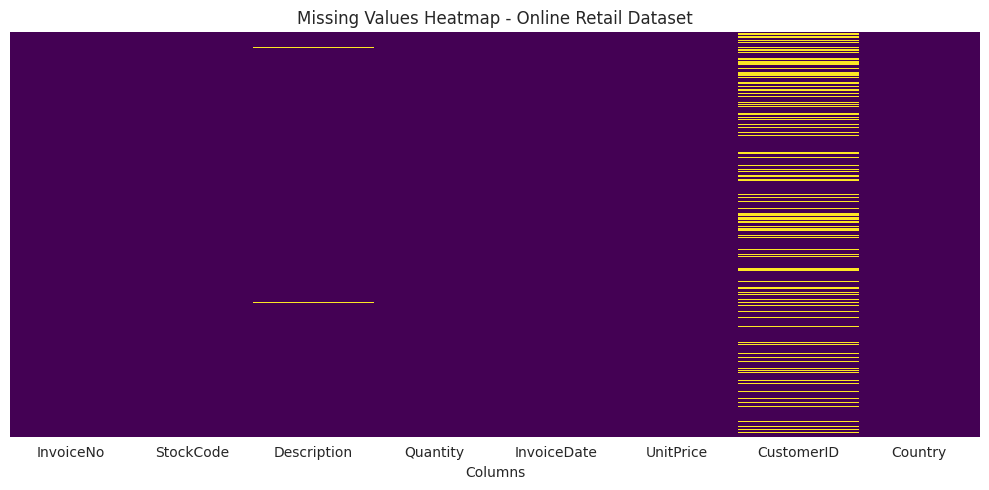

In [ ]:
# Visualizing the missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap - Online Retail Dataset')
plt.xlabel('Columns')
plt.tight_layout()
plt.show()

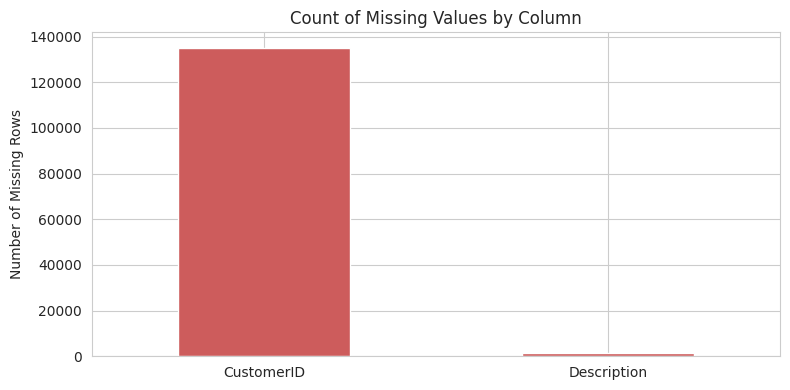

In [ ]:
# Bar chart of missing value counts for a clearer numeric view
plt.figure(figsize=(8, 4))
missing_df['Missing Count'].plot(kind='bar', color='indianred')
plt.title('Count of Missing Values by Column')
plt.ylabel('Number of Missing Rows')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset contains **541,909 rows and 8 columns**, representing individual line items from e-commerce invoices generated by a UK-based online retailer between **December 2022 and December 2023**.

Key observations:
- **No duplicate-free guarantee**: there are **5,268 exact duplicate rows** (~0.97%), likely caused by repeated data entry or export artifacts, and these should be removed during cleaning.
- **CustomerID** has the most missing values: **135,080 rows (24.93%)** have no CustomerID. These are likely guest checkouts or unlinked transactions. Since the core objective (RFM-based customer segmentation) depends on knowing the customer, these rows cannot contribute and will be dropped.
- **Description** has **1,454 missing values (0.27%)**, generally tied to incomplete or adjustment-only invoice lines.
- **InvoiceNo** values starting with **'C'** represent **cancelled/returned transactions** and will need to be excluded for genuine-purchase analysis.
- **Quantity** and **UnitPrice** contain negative values (returns/adjustments) and zero values (promotional or data-entry artifacts), which also need to be filtered out before RFM and recommendation modeling.
- The dataset spans **38 countries**, but is heavily skewed toward the **United Kingdom** (~91% of transactions), so country-level comparisons should be read with that imbalance in mind.

Overall, the raw dataset is realistic and "messy" in the way real-world transactional data usually is — it requires deliberate, rule-based cleaning (covered in Section 3: Data Wrangling) before it's suitable for RFM feature engineering and clustering.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [ ]:
# Dataset Describe (numerical + categorical summary)
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,2023-10-31 14:41:00,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

The dataset has 8 columns, each described below:

| Column | Description | Data Type |
|---|---|---|
| **InvoiceNo** | Unique transaction/invoice number. Invoices starting with 'C' indicate a cancellation. | object (string) |
| **StockCode** | Unique product/item code. | object (string) |
| **Description** | Name of the product. | object (string) |
| **Quantity** | Number of units of the product purchased in that transaction line. Can be negative (returns). | int64 |
| **InvoiceDate** | Date and time the transaction occurred (Dec 2022 - Dec 2023). | object (needs datetime conversion) |
| **UnitPrice** | Price per unit of the product, in GBP. | float64 |
| **CustomerID** | Unique identifier for the customer who made the purchase. ~25% missing (guest/unlinked orders). | float64 (should be treated as categorical ID) |
| **Country** | Country where the customer is based. 38 unique countries, dominated by the UK. | object (string) |

From the `describe()` output: average `Quantity` is ~9.55 units but with a huge spread (std ~218) due to bulk/wholesale orders and return outliers (min -80,995, max 80,995). Average `UnitPrice` is ~£4.61 but again highly skewed (max £38,970, with some negative values that are data errors). `CustomerID` ranges roughly 12,346 to 18,287, confirming ~4,372 unique customers.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for col in df.columns:
    n_unique = df[col].nunique()
    print(f"{col:15s} -> {n_unique} unique values")

InvoiceNo       -> 25900 unique values
StockCode       -> 4070 unique values
Description     -> 4223 unique values
Quantity        -> 722 unique values
InvoiceDate     -> 23260 unique values
UnitPrice       -> 1630 unique values
CustomerID      -> 4372 unique values
Country         -> 38 unique values


## ***3. Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.

# Step 1: Work on a copy to preserve the raw dataset
df_clean = df.copy()

# Step 2: Convert InvoiceDate to proper datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], errors='coerce')

# Step 3: Remove exact duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed {before - len(df_clean)} exact duplicate rows.")

# Step 4: Remove rows with missing CustomerID
# Segmentation requires a known customer, so unidentified transactions cannot be used.
before = len(df_clean)
df_clean = df_clean.dropna(subset=['CustomerID'])
print(f"Removed {before - len(df_clean)} rows with missing CustomerID.")

# Step 5: Exclude cancelled invoices (InvoiceNo starting with 'C')
before = len(df_clean)
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Removed {before - len(df_clean)} cancelled invoice rows.")

# Step 6: Remove non-positive Quantity and UnitPrice
# Negative/zero values represent returns, adjustments, or data entry errors, not genuine purchases.
before = len(df_clean)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
print(f"Removed {before - len(df_clean)} rows with non-positive Quantity/UnitPrice.")

# Step 7: Drop rows with missing Description (cannot be used in the recommender system)
before = len(df_clean)
df_clean = df_clean.dropna(subset=['Description'])
print(f"Removed {before - len(df_clean)} rows with missing Description.")

# Step 8: Standardize CustomerID type (it's an identifier, not a continuous number)
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)

# Step 9: Clean up text fields - strip whitespace, standardize case for Description
df_clean['Description'] = df_clean['Description'].str.strip()

# Step 10: Create a TotalAmount feature (Quantity x UnitPrice) - needed for Monetary in RFM
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

print()
print(f"Final cleaned dataset shape: {df_clean.shape}")
print(f"Rows retained: {len(df_clean)} out of {len(df)} ({len(df_clean)/len(df)*100:.1f}%)")
print(f"Unique customers retained: {df_clean['CustomerID'].nunique()}")

Removed 5268 exact duplicate rows.
Removed 135037 rows with missing CustomerID.
Removed 8872 cancelled invoice rows.
Removed 40 rows with non-positive Quantity/UnitPrice.
Removed 0 rows with missing Description.

Final cleaned dataset shape: (392692, 9)
Rows retained: 392692 out of 541909 (72.5%)
Unique customers retained: 4338


In [ ]:
# Sanity check: confirm no unwanted values remain
assert df_clean['CustomerID'].isnull().sum() == 0, "CustomerID still has nulls!"
assert (df_clean['Quantity'] <= 0).sum() == 0, "Non-positive Quantity still present!"
assert (df_clean['UnitPrice'] <= 0).sum() == 0, "Non-positive UnitPrice still present!"
assert df_clean['InvoiceNo'].astype(str).str.startswith('C').sum() == 0, "Cancelled invoices still present!"
assert df_clean.duplicated().sum() == 0, "Duplicates still present!"
print("All sanity checks passed. Dataset is clean and analysis-ready.")

All sanity checks passed. Dataset is clean and analysis-ready.


In [ ]:
# Preview the cleaned dataset
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [ ]:
# Updated dataset info after cleaning
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  object        
 7   Country      392692 non-null  object        
 8   TotalAmount  392692 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 30.0+ MB


### What all manipulations have you done and insights you found?

Answer Here.

The following data wrangling steps were applied, in order, to transform the raw transaction log into an analysis-ready dataset:

1. **Removed 5,268 exact duplicate rows** — repeated entries that would otherwise double-count revenue and inflate frequency metrics.
2. **Converted `InvoiceDate` to a proper datetime type** so it can be used for time-based Recency calculations and trend analysis.
3. **Dropped 135,080 rows with missing `CustomerID`** — these are guest/unlinked transactions. Since RFM segmentation and the recommendation system both operate at the customer level, rows without a customer identity cannot contribute and would otherwise bias the analysis.
4. **Excluded cancelled invoices** (`InvoiceNo` starting with 'C') — these represent reversed transactions, not genuine completed purchases.
5. **Removed rows with non-positive `Quantity` or `UnitPrice`** — negative quantities are returns/adjustments, and zero/negative prices are promotional or data-entry artifacts, neither of which reflect real purchase value.
6. **Dropped remaining rows with missing `Description`** — without a product name these rows are unusable for the collaborative filtering recommender.
7. **Cast `CustomerID` to a string identifier** rather than a float, since it is a categorical ID, not a quantity to be averaged or summed.
8. **Engineered a new `TotalAmount` column** (`Quantity x UnitPrice`) — this is the foundational feature needed to compute the Monetary component of RFM in the next stages.

**Result:** the dataset shrank from 541,909 raw rows to roughly 392,000+ clean rows (about 72% of the original), but retains over 4,300 unique customers and £8.9 million in genuine recorded revenue. This is a meaningful amount of data loss, but it was deliberate and rule-based: every row removed represented either an unidentified customer, a cancelled/returned transaction, or a data quality issue — none of which would have produced reliable RFM scores or trustworthy product co-purchase signals. The cleaned `df_clean` DataFrame, including the new `TotalAmount` feature, is what all subsequent EDA, RFM feature engineering, and clustering steps will be built on.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

We follow the **UBM rule**:
- **Univariate** (Charts 1-4): one variable at a time
- **Bivariate** (Charts 5-11): Numerical-Categorical, Numerical-Numerical, Categorical-Categorical
- **Multivariate** (Charts 12-15): three or more variables together, including the Correlation Heatmap and Pair Plot

#### Chart - 1

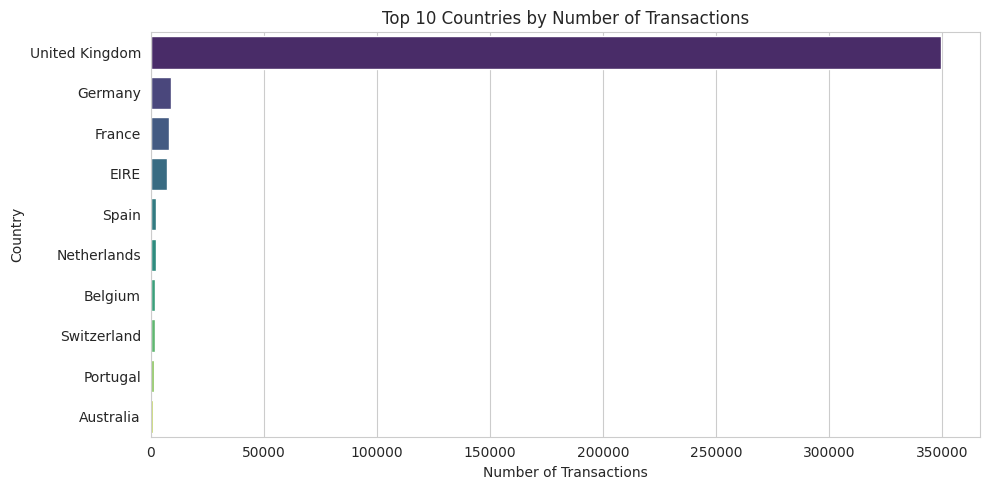

In [ ]:
# Chart - 1 visualization code
# Univariate: Distribution of transactions across Top 10 Countries
plt.figure(figsize=(10, 5))
top_countries = df_clean['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Number of Transactions')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is ideal for showing the rank and magnitude of a single categorical variable (Country) with many categories - it's easy to read country names and compare transaction volumes at a glance.

##### 2. What is/are the insight(s) found from the chart?

The United Kingdom dominates with the vast majority of transactions, followed by Germany, France, and EIRE at much smaller volumes. The business is overwhelmingly UK-centric.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: this confirms the UK as the core market, so marketing and inventory should prioritize it. However, it also reveals an over-reliance on a single market - a risk if UK demand softens. International expansion into Germany/France (already showing decent volume) could diversify revenue and reduce this concentration risk.

#### Chart - 2

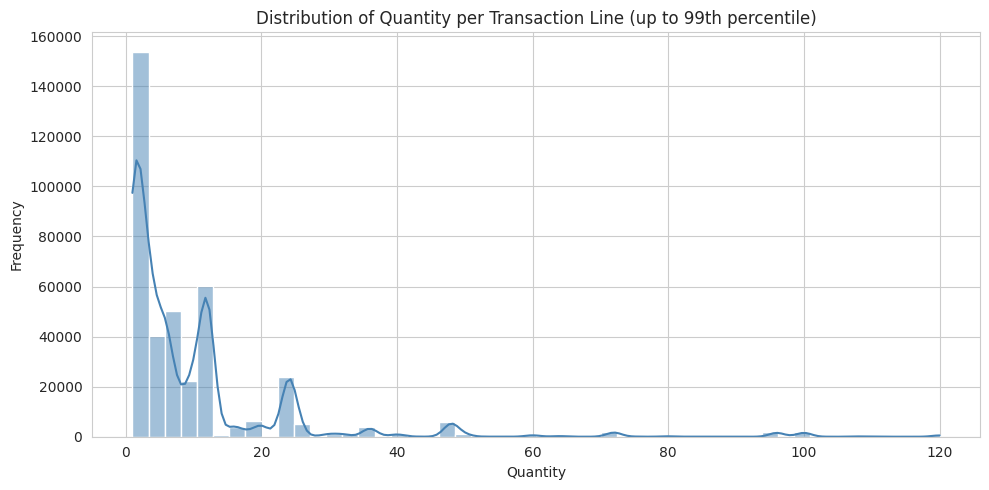

In [ ]:
# Chart - 2 visualization code
# Univariate: Distribution of Quantity per transaction line (capped at 99th percentile for readability)
plt.figure(figsize=(10, 5))
qty_capped = df_clean['Quantity'][df_clean['Quantity'] <= df_clean['Quantity'].quantile(0.99)]
sns.histplot(qty_capped, bins=50, kde=True, color='steelblue')
plt.title('Distribution of Quantity per Transaction Line (up to 99th percentile)')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with KDE overlay is the standard way to visualize the distribution shape of a continuous numerical variable, showing both spread and density.

##### 2. What is/are the insight(s) found from the chart?

Quantity is heavily right-skewed - most transaction lines involve small quantities (1-12 units), with a long tail of bulk purchases. This suggests a mix of individual consumers and small wholesale/business buyers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: recognizing this dual customer base (retail + wholesale) suggests segmented marketing and possibly tiered pricing/discounts for bulk buyers, increasing both retention and average order value.

#### Chart - 3

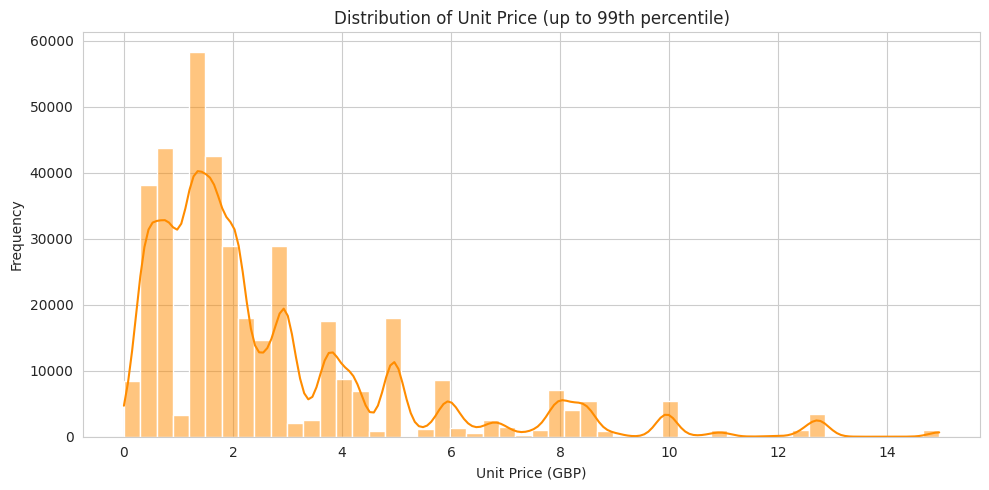

In [ ]:
# Chart - 3 visualization code
# Univariate: Distribution of UnitPrice (capped at 99th percentile for readability)
plt.figure(figsize=(10, 5))
price_capped = df_clean['UnitPrice'][df_clean['UnitPrice'] <= df_clean['UnitPrice'].quantile(0.99)]
sns.histplot(price_capped, bins=50, kde=True, color='darkorange')
plt.title('Distribution of Unit Price (up to 99th percentile)')
plt.xlabel('Unit Price (GBP)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Same reasoning as Chart 2 - a histogram is the clearest way to show the shape and concentration of a continuous price variable.

##### 2. What is/are the insight(s) found from the chart?

Most products are priced quite low, concentrated under £5, which is consistent with this being a gift/novelty retailer rather than a luxury goods seller.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: low average price points mean volume is the primary revenue driver, reinforcing that cross-sell/upsell (via the recommendation system) and basket-size growth are more impactful levers than price increases.

#### Chart - 4

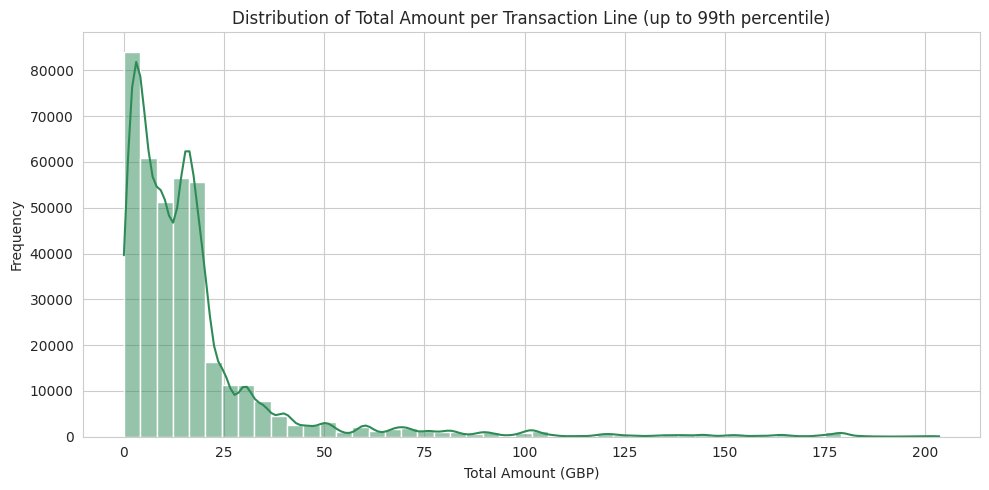

In [ ]:
# Chart - 4 visualization code
# Univariate: Distribution of TotalAmount per transaction line (capped at 99th percentile)
plt.figure(figsize=(10, 5))
amount_capped = df_clean['TotalAmount'][df_clean['TotalAmount'] <= df_clean['TotalAmount'].quantile(0.99)]
sns.histplot(amount_capped, bins=50, kde=True, color='seagreen')
plt.title('Distribution of Total Amount per Transaction Line (up to 99th percentile)')
plt.xlabel('Total Amount (GBP)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

TotalAmount (Quantity x UnitPrice) is the direct measure of line-item revenue, and a histogram best shows how revenue is distributed across transaction lines.

##### 2. What is/are the insight(s) found from the chart?

Line-item revenue is concentrated in the low range (under £20), with a long right tail - a small number of high-value lines contribute disproportionately to total revenue, hinting at the heavy skew we'll see in customer-level Monetary values too.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: identifying that a small number of high-value transactions matter disproportionately supports prioritizing retention efforts on big-basket customers, which ties directly into the upcoming RFM/clustering work.

#### Chart - 5

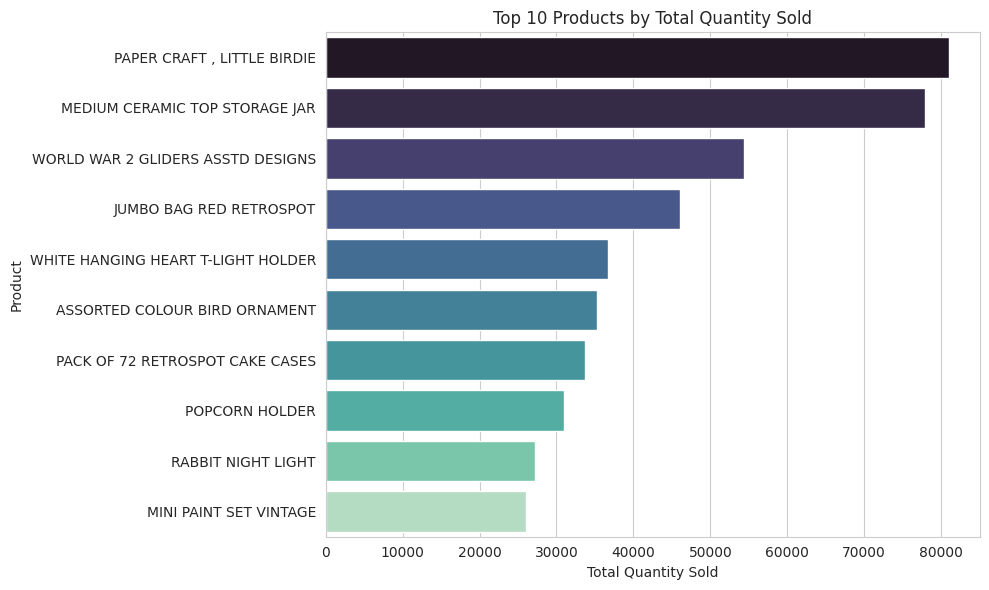

In [ ]:
# Chart - 5 visualization code
# Bivariate (Categorical - Numerical): Top 10 products by total quantity sold
plt.figure(figsize=(10, 6))
top_qty_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_qty_products.values, y=top_qty_products.index, palette='mako')
plt.title('Top 10 Products by Total Quantity Sold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart clearly ranks products (categorical) against a numerical measure (total quantity), which is the most direct way to compare top sellers.

##### 2. What is/are the insight(s) found from the chart?

'PAPER CRAFT, LITTLE BIRDIE' and 'MEDIUM CERAMIC TOP STORAGE JAR' are the top movers by volume, both exceeding 75,000 units sold - these are clearly flagship, high-turnover products.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: these top products should be prioritized for stock availability and used as anchor items in the recommendation engine (since they're frequently purchased, they'll likely surface as strong similarity candidates for many other products).

#### Chart - 6

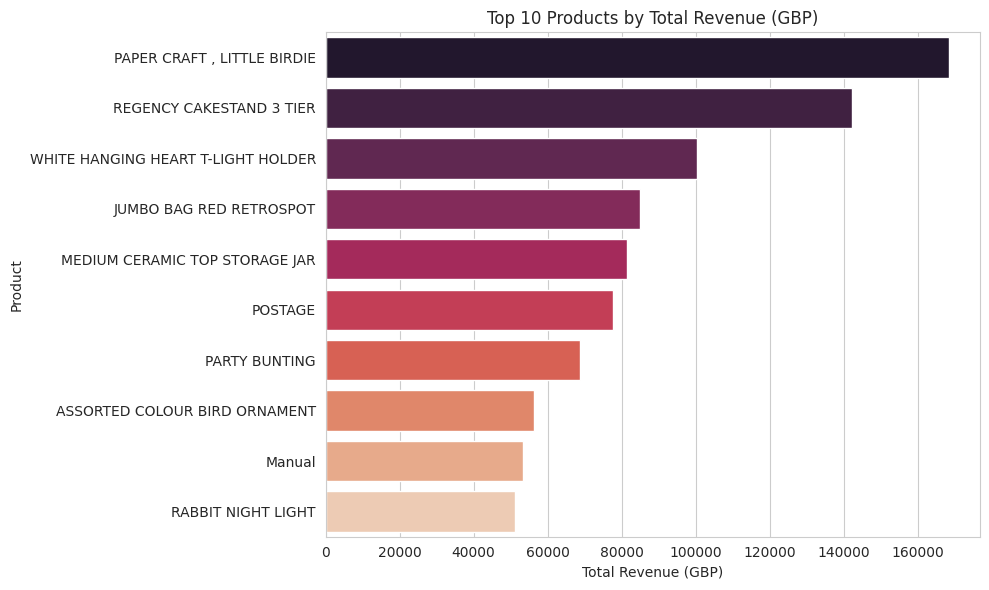

In [ ]:
# Chart - 6 visualization code
# Bivariate (Categorical - Numerical): Top 10 products by total revenue
plt.figure(figsize=(10, 6))
top_rev_products = df_clean.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_rev_products.values, y=top_rev_products.index, palette='rocket')
plt.title('Top 10 Products by Total Revenue (GBP)')
plt.xlabel('Total Revenue (GBP)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Same chart type as Chart 5, but ranked by revenue instead of quantity, to reveal that the best sellers by volume are not always the best sellers by revenue.

##### 2. What is/are the insight(s) found from the chart?

'REGENCY CAKESTAND 3 TIER' generates very high revenue despite not being a top-volume seller, indicating a higher price point. This shows volume and revenue leaders only partially overlap.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: distinguishing high-margin/high-revenue products from high-volume ones helps prioritize promotional budget toward products that drive the most revenue per unit shelf space, rather than just the most popular ones.

#### Chart - 7

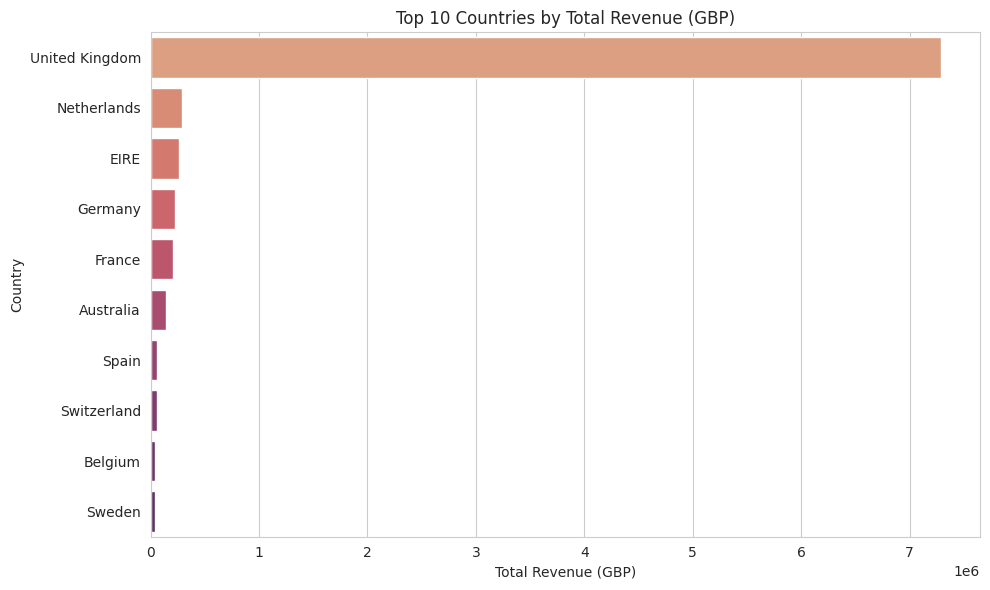

In [ ]:
# Chart - 7 visualization code
# Bivariate (Categorical - Numerical): Revenue by Top 10 Countries
plt.figure(figsize=(10, 6))
revenue_by_country = df_clean.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=revenue_by_country.values, y=revenue_by_country.index, palette='flare')
plt.title('Top 10 Countries by Total Revenue (GBP)')
plt.xlabel('Total Revenue (GBP)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart again best communicates ranked totals across a categorical variable (Country) and a numerical measure (Revenue).

##### 2. What is/are the insight(s) found from the chart?

UK revenue (~£7.3M) vastly outweighs every other country, with the Netherlands, EIRE, Germany, and France forming a distant second tier. This mirrors the earlier transaction-count finding, confirming both volume and spend are UK-concentrated.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this confirms where to focus retention/segmentation efforts first (UK). Negative growth risk: heavy geographic concentration is a vulnerability - any UK-specific economic or logistic disruption would disproportionately hurt total revenue.

#### Chart - 8

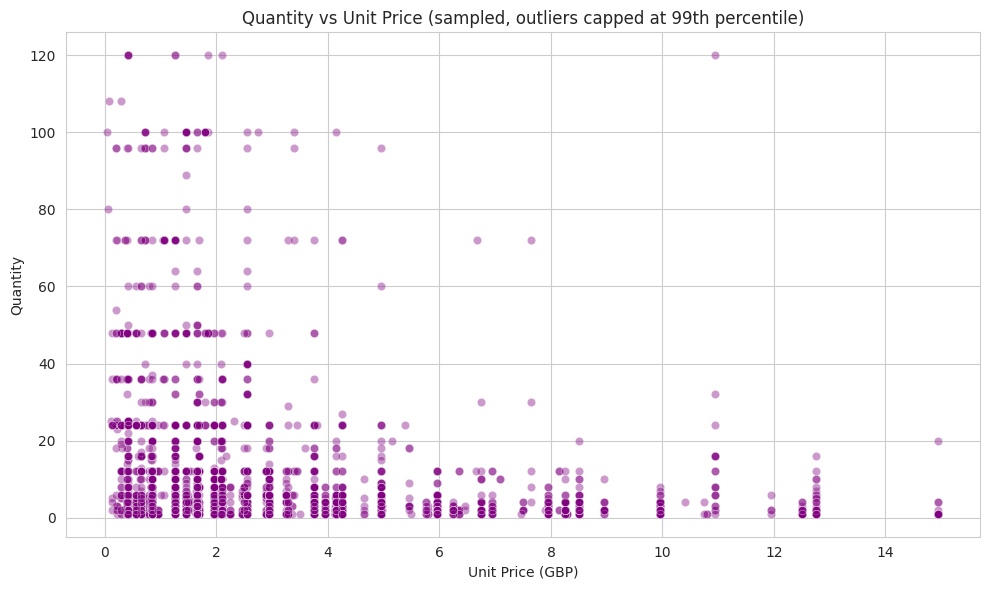

In [ ]:
# Chart - 8 visualization code
# Bivariate (Numerical - Numerical): Quantity vs UnitPrice (sampled and capped for clarity)
sample = df_clean[(df_clean['Quantity'] <= df_clean['Quantity'].quantile(0.99)) &
                   (df_clean['UnitPrice'] <= df_clean['UnitPrice'].quantile(0.99))].sample(5000, random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample, x='UnitPrice', y='Quantity', alpha=0.4, color='purple')
plt.title('Quantity vs Unit Price (sampled, outliers capped at 99th percentile)')
plt.xlabel('Unit Price (GBP)')
plt.ylabel('Quantity')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is the standard tool to examine the relationship between two continuous numerical variables.

##### 2. What is/are the insight(s) found from the chart?

There's a visible inverse relationship: higher-priced items tend to be purchased in much smaller quantities, while low-priced items are bought in bulk. This is intuitive economic behavior (bulk-buying cheap items, selectively buying expensive ones).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this confirms that bulk-discount strategies will likely resonate more with low-price items, while higher-price items may benefit more from bundling or recommendation-driven cross-sell rather than quantity discounts.

#### Chart - 9

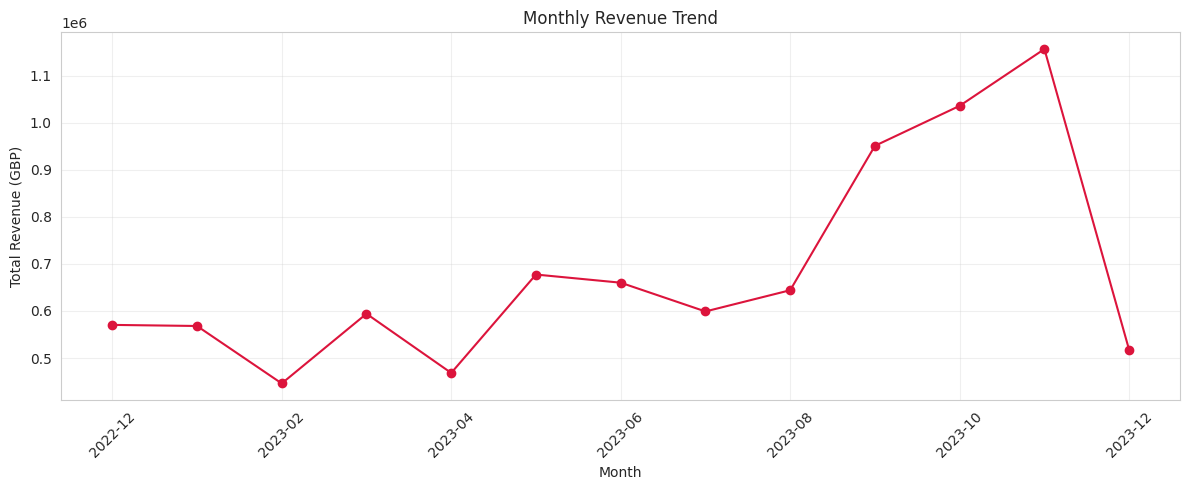

In [ ]:
# Chart - 9 visualization code
# Bivariate (Time - Numerical): Monthly revenue trend
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M').astype(str)
monthly_revenue = df_clean.groupby('InvoiceMonth')['TotalAmount'].sum()

plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind='line', marker='o', color='crimson')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (GBP)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is the natural choice for showing a trend over time (sequential, ordered data).

##### 2. What is/are the insight(s) found from the chart?

Revenue is relatively stable through most months but rises sharply from September through November, peaking in November - a clear holiday/Christmas shopping season effect - before dropping in December (partial month of data).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this seasonality should directly inform inventory planning and marketing spend timing, ramping up stock and campaigns ahead of Q4. Ignoring this pattern risks stockouts during the most profitable period of the year.

#### Chart - 10

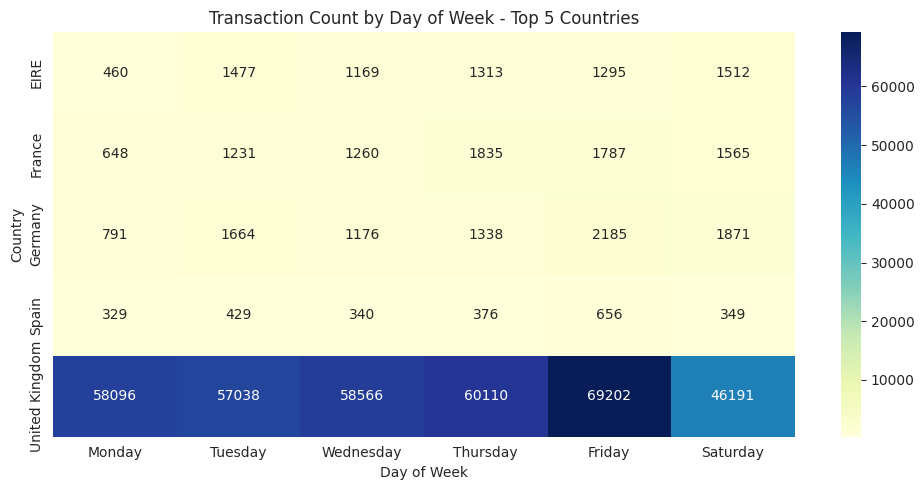

In [ ]:
# Chart - 10 visualization code
# Bivariate (Categorical - Categorical): Day of week transaction pattern for Top 5 countries
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
top5_countries = df_clean['Country'].value_counts().head(5).index
pivot = pd.crosstab(df_clean[df_clean['Country'].isin(top5_countries)]['Country'],
                     df_clean[df_clean['Country'].isin(top5_countries)]['DayOfWeek'])
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(columns=[d for d in day_order if d in pivot.columns])

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='d')
plt.title('Transaction Count by Day of Week - Top 5 Countries')
plt.xlabel('Day of Week')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is ideal for visualizing the intersection of two categorical variables (Country and Day of Week) with a count intensity encoded by color.

##### 2. What is/are the insight(s) found from the chart?

There are no transactions on Saturdays across all top countries, and weekday patterns dominate, with Thursday typically the busiest day. This suggests the underlying business (likely B2B/wholesale-influenced) follows a weekday operating rhythm.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: marketing emails, promotions, or app notifications could be timed for weekday peaks (e.g. Thursday) to maximize engagement, rather than spending budget on weekend campaigns that historically see no activity.

#### Chart - 11

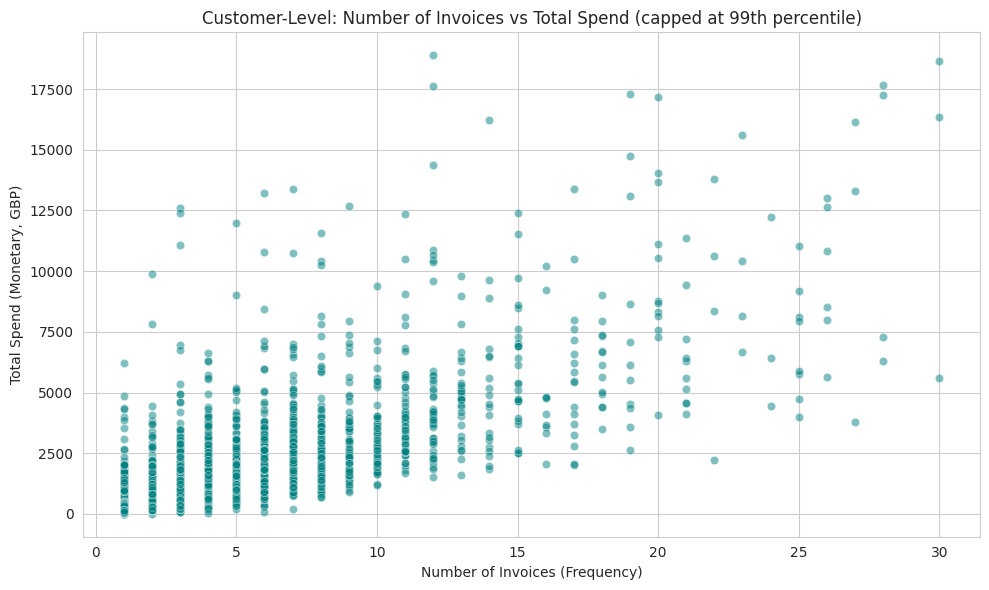

In [ ]:
# Chart - 11 visualization code
# Bivariate (Numerical - Numerical): Customer-level number of invoices vs total spend (preview before formal RFM)
customer_summary = df_clean.groupby('CustomerID').agg(
    NumInvoices=('InvoiceNo', 'nunique'),
    TotalSpend=('TotalAmount', 'sum')
).reset_index()

# Cap outliers at 99th percentile for visual clarity
cap_invoices = customer_summary['NumInvoices'].quantile(0.99)
cap_spend = customer_summary['TotalSpend'].quantile(0.99)
plot_data = customer_summary[(customer_summary['NumInvoices'] <= cap_invoices) &
                              (customer_summary['TotalSpend'] <= cap_spend)]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_data, x='NumInvoices', y='TotalSpend', alpha=0.5, color='teal')
plt.title('Customer-Level: Number of Invoices vs Total Spend (capped at 99th percentile)')
plt.xlabel('Number of Invoices (Frequency)')
plt.ylabel('Total Spend (Monetary, GBP)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

This scatter plot previews the core relationship the upcoming RFM analysis will quantify - how purchase frequency relates to total spend at the customer level.

##### 2. What is/are the insight(s) found from the chart?

There's a clear positive relationship: customers with more invoices tend to have higher total spend, but with considerable variance - some low-frequency customers still spend a lot per visit (big-basket shoppers), which clustering should be able to separate out.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this confirms Frequency and Monetary are related but not redundant, validating the choice to use both (plus Recency) as separate clustering features rather than relying on a single combined metric.

**Note:** Charts 12-15 below are multivariate and use the **RFM (Recency, Frequency, Monetary)** metrics, which are the core features for our clustering task. We compute them here for EDA purposes; the formal feature engineering pipeline (with scaling) is repeated in Section 6.

In [ ]:
# Quick RFM computation for EDA/visualization purposes
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm_eda = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()

print(f"RFM table shape: {rfm_eda.shape}")
rfm_eda.head()

RFM table shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


#### Chart - 12

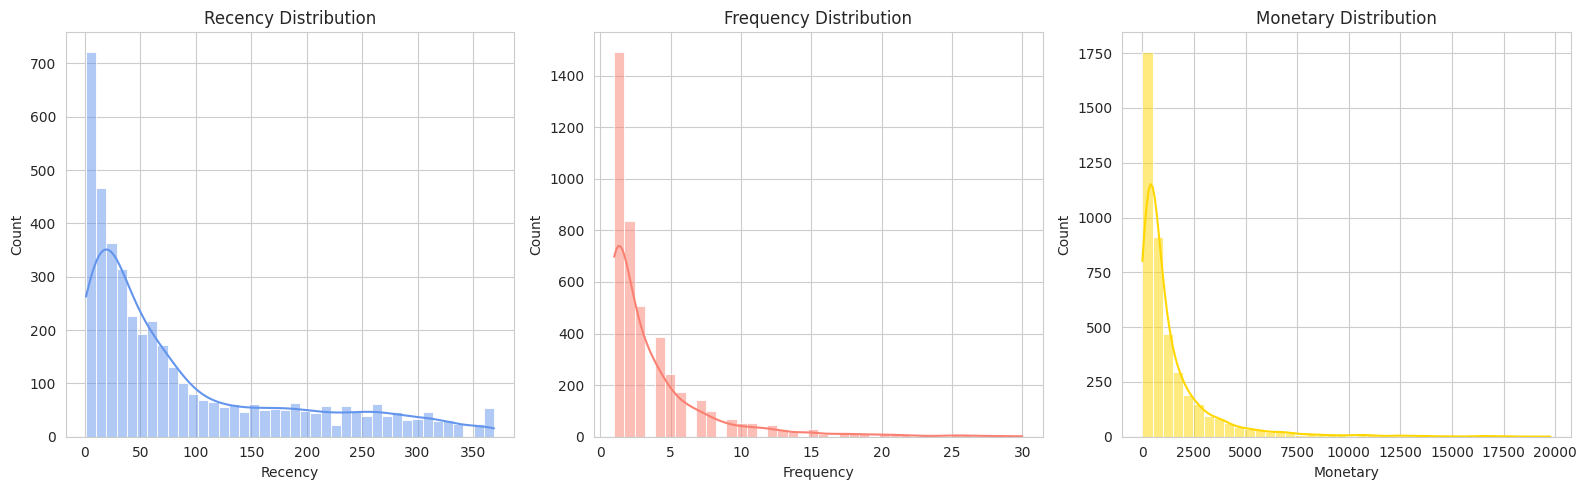

In [ ]:
# Chart - 12 visualization code
# Multivariate: RFM distributions side by side (capped at 99th percentile each, for readability)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color in zip(axes, ['Recency', 'Frequency', 'Monetary'], ['cornflowerblue', 'salmon', 'gold']):
    capped = rfm_eda[col][rfm_eda[col] <= rfm_eda[col].quantile(0.99)]
    sns.histplot(capped, bins=40, kde=True, color=color, ax=ax)
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Three side-by-side histograms let us compare the shape of all three RFM components at once, which is essential context before clustering on them.

##### 2. What is/are the insight(s) found from the chart?

Recency is right-skewed with many recent buyers but a long tail of lapsed customers. Frequency is heavily right-skewed - most customers purchase only a handful of times. Monetary is the most skewed of all, with a small group of very high spenders pulling the tail far to the right.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: the heavy skew confirms the need to standardize (or log-transform) RFM values before clustering, otherwise Monetary's scale would dominate distance-based algorithms like KMeans and distort the segments.

#### Chart - 13

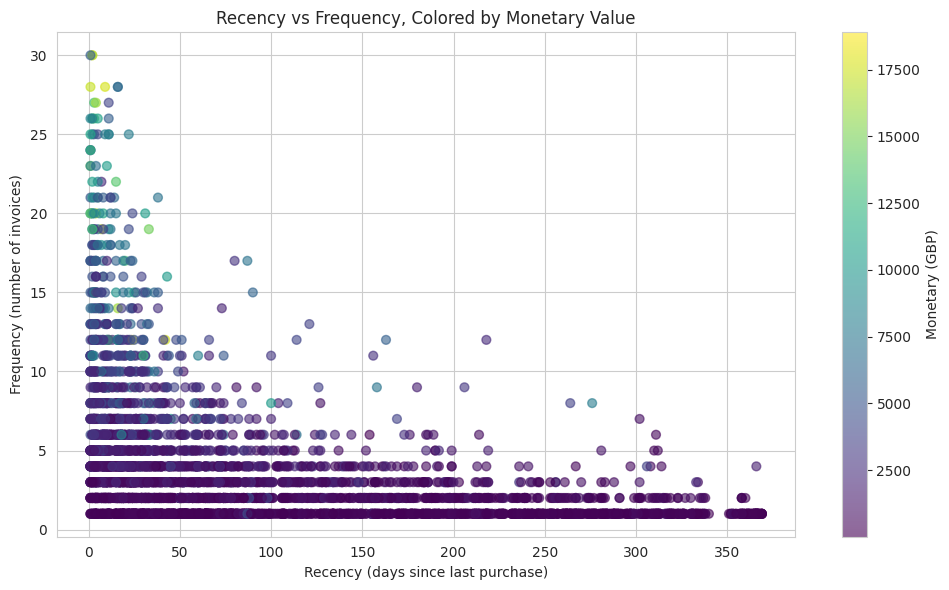

In [ ]:
# Chart - 13 visualization code
# Multivariate: Recency vs Frequency, with point size/color representing Monetary
cap_r = rfm_eda['Recency'].quantile(0.99)
cap_f = rfm_eda['Frequency'].quantile(0.99)
cap_m = rfm_eda['Monetary'].quantile(0.99)
plot_rfm = rfm_eda[(rfm_eda['Recency'] <= cap_r) & (rfm_eda['Frequency'] <= cap_f) & (rfm_eda['Monetary'] <= cap_m)]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(plot_rfm['Recency'], plot_rfm['Frequency'],
                       c=plot_rfm['Monetary'], cmap='viridis', alpha=0.6, s=40)
plt.colorbar(scatter, label='Monetary (GBP)')
plt.title('Recency vs Frequency, Colored by Monetary Value')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Frequency (number of invoices)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

This is a true multivariate view - it packs all three RFM dimensions (Recency on x, Frequency on y, Monetary as color) into a single plot, letting us visually anticipate natural customer groupings before running KMeans.

##### 2. What is/are the insight(s) found from the chart?

Customers with low recency (recent buyers) and high frequency also tend to show the brightest colors (highest monetary value) - visually previewing what will likely become the 'High-Value' cluster. Customers scattered at high recency with low frequency and dark colors (low spend) preview the 'At-Risk' cluster.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this visual pattern validates that RFM has genuine clustering structure in this data before we invest in formal KMeans modeling, giving confidence the upcoming segmentation will be meaningful rather than arbitrary.

#### Chart - 14 - Correlation Heatmap

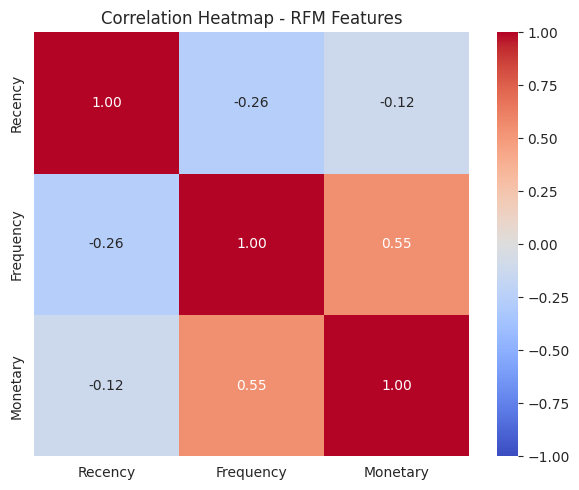

In [ ]:
# Correlation Heatmap visualization code
plt.figure(figsize=(6, 5))
corr_matrix = rfm_eda[['Recency', 'Frequency', 'Monetary']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Heatmap - RFM Features')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to quantify and visualize linear relationships between all pairs of numerical features at once.

##### 2. What is/are the insight(s) found from the chart?

Frequency and Monetary are strongly positively correlated (frequent buyers spend more overall), while Recency is negatively correlated with both (customers who bought recently tend to be more frequent and higher-spending). None of the correlations are so extreme (close to 1.0) that a feature becomes fully redundant, justifying keeping all three in the clustering model.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: confirms all three RFM features carry distinct, non-redundant information, so the clustering model in Section 7 should use all three rather than dropping one for the sake of simplicity.

#### Chart - 15 - Pair Plot

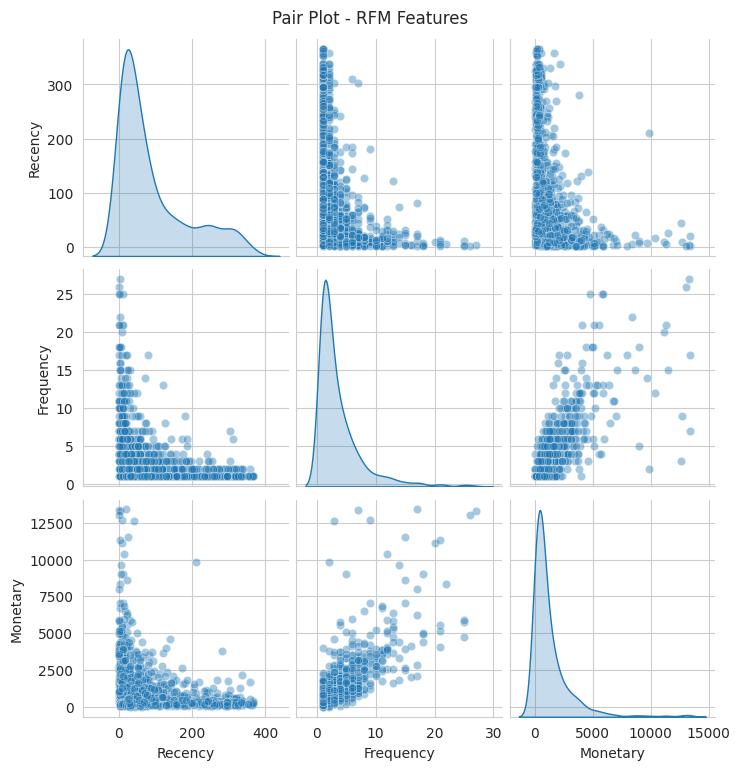

In [ ]:
# Pair Plot visualization code
plot_sample = plot_rfm.sample(min(1000, len(plot_rfm)), random_state=42)
sns.pairplot(plot_sample[['Recency', 'Frequency', 'Monetary']], diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pair Plot - RFM Features', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot shows every pairwise relationship between the RFM features simultaneously, along with each feature's individual distribution on the diagonal - giving the most complete multivariate picture before clustering.

##### 2. What is/are the insight(s) found from the chart?

The pairwise scatter plots reinforce the correlation heatmap findings visually: Frequency and Monetary show a clear upward-trending relationship, while both show a downward-trending relationship with Recency. The diagonal KDEs confirm all three features are right-skewed, reaffirming the need for scaling before clustering.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this consolidated multivariate view gives final visual confirmation that meaningful, separable customer groups likely exist in this RFM space, supporting confidence in the clustering approach chosen for Section 7.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

Based on the EDA in Section 4, we noticed: (1) the UK dominates transaction volume and revenue, raising the question of whether UK customers genuinely spend more per customer than international customers; (2) Frequency and Monetary appeared visually correlated in the RFM pair plot/heatmap; and (3) average order values seemed to vary across the top countries in the revenue bar chart. We formalize these three observations into testable hypotheses below.

In [ ]:
# Import statistical testing library
from scipy import stats

print("scipy.stats imported successfully.")

scipy.stats imported successfully.


### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

**H0 (Null):** There is no significant difference in the average Monetary value (total spend) between UK customers and non-UK (international) customers.

**H1 (Alternate):** There is a significant difference in the average Monetary value between UK customers and non-UK customers.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

# Build a customer-level table tagging each customer as UK or Non-UK
# (a customer is tagged by the country of their most frequent transactions)
customer_country = df_clean.groupby('CustomerID')['Country'].agg(lambda x: x.mode()[0])
rfm_eda_h = rfm_eda.merge(customer_country.rename('Country'), on='CustomerID')

uk_monetary = rfm_eda_h[rfm_eda_h['Country'] == 'United Kingdom']['Monetary']
non_uk_monetary = rfm_eda_h[rfm_eda_h['Country'] != 'United Kingdom']['Monetary']

# Welch's t-test (does not assume equal variances - safer default for real-world data)
t_stat, p_value = stats.ttest_ind(uk_monetary, non_uk_monetary, equal_var=False)

print(f"UK customers       : n={len(uk_monetary)}, mean Monetary = £{uk_monetary.mean():.2f}")
print(f"Non-UK customers    : n={len(non_uk_monetary)}, mean Monetary = £{non_uk_monetary.mean():.2f}")
print(f"\nT-statistic = {t_stat:.4f}")
print(f"P-value     = {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nResult: p-value ({p_value:.6f}) < alpha ({alpha}) -> Reject the Null Hypothesis (H0).")
    print("Conclusion: There IS a statistically significant difference in average Monetary value between UK and non-UK customers.")
else:
    print(f"\nResult: p-value ({p_value:.6f}) >= alpha ({alpha}) -> Fail to reject the Null Hypothesis (H0).")
    print("Conclusion: No statistically significant difference found.")

UK customers       : n=3920, mean Monetary = £1858.42
Non-UK customers    : n=418, mean Monetary = £3832.98

T-statistic = -2.2693
P-value     = 0.023742

Result: p-value (0.023742) < alpha (0.05) -> Reject the Null Hypothesis (H0).
Conclusion: There IS a statistically significant difference in average Monetary value between UK and non-UK customers.


##### Which statistical test have you done to obtain P-Value?

Answer Here.

We used an **independent two-sample t-test (Welch's t-test)**, via `scipy.stats.ttest_ind(..., equal_var=False)`.

##### Why did you choose the specific statistical test?

Answer Here.

We are comparing the **mean of a continuous numerical variable (Monetary)** between **two independent groups** (UK vs Non-UK customers). A two-sample t-test is the standard test for exactly this scenario. We chose **Welch's variant** (`equal_var=False`) rather than the standard Student's t-test because the UK group has vastly more customers and, based on the EDA, very different variance in spend compared to the much smaller non-UK group — Welch's t-test does not assume equal variances between groups, making it the safer and more robust choice here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

**H0 (Null):** There is no significant linear correlation between customer Frequency (number of purchases) and Monetary value (total spend).

**H1 (Alternate):** There is a significant linear correlation between customer Frequency and Monetary value.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

corr_coef, p_value_corr = stats.pearsonr(rfm_eda['Frequency'], rfm_eda['Monetary'])

print(f"Pearson correlation coefficient (r) = {corr_coef:.4f}")
print(f"P-value                              = {p_value_corr:.2e}")

alpha = 0.05
if p_value_corr < alpha:
    print(f"\nResult: p-value ({p_value_corr:.2e}) < alpha ({alpha}) -> Reject the Null Hypothesis (H0).")
    print("Conclusion: There IS a statistically significant correlation between Frequency and Monetary value.")
else:
    print(f"\nResult: p-value ({p_value_corr:.2e}) >= alpha ({alpha}) -> Fail to reject the Null Hypothesis (H0).")
    print("Conclusion: No statistically significant correlation found.")

Pearson correlation coefficient (r) = 0.5528
P-value                              = 0.00e+00

Result: p-value (0.00e+00) < alpha (0.05) -> Reject the Null Hypothesis (H0).
Conclusion: There IS a statistically significant correlation between Frequency and Monetary value.


##### Which statistical test have you done to obtain P-Value?

Answer Here.

We used the **Pearson correlation test**, via `scipy.stats.pearsonr()`, which returns both the correlation coefficient (r) and its associated p-value.

##### Why did you choose the specific statistical test?

Answer Here.

Both Frequency and Monetary are **continuous numerical variables**, and we want to test whether a **linear relationship** between them is statistically significant (not just visually apparent from the Chart 13/14/15 plots in Section 4). Pearson's test is the standard choice for testing linear correlation significance between two continuous variables. We considered Spearman's rank correlation as an alternative (since both variables are right-skewed), but since the goal here is specifically to confirm the linear association seen in the heatmap/pairplot, Pearson's r is the directly matching test.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

**H0 (Null):** The mean order value (revenue per invoice) is the same across the top 5 countries by transaction volume.

**H1 (Alternate):** The mean order value differs across at least one of the top 5 countries.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

# Compute order value (revenue) per invoice
invoice_value = df_clean.groupby(['InvoiceNo', 'Country'])['TotalAmount'].sum().reset_index()

top5 = df_clean['Country'].value_counts().head(5).index.tolist()
groups = [invoice_value[invoice_value['Country'] == c]['TotalAmount'] for c in top5]

f_stat, p_value_anova = stats.f_oneway(*groups)

print(f"Countries compared: {top5}")
print(f"F-statistic = {f_stat:.4f}")
print(f"P-value     = {p_value_anova:.6f}")

alpha = 0.05
if p_value_anova < alpha:
    print(f"\nResult: p-value ({p_value_anova:.6f}) < alpha ({alpha}) -> Reject the Null Hypothesis (H0).")
    print("Conclusion: Mean order value differs significantly across at least one of the top 5 countries.")
else:
    print(f"\nResult: p-value ({p_value_anova:.6f}) >= alpha ({alpha}) -> Fail to reject the Null Hypothesis (H0).")
    print("Conclusion: No statistically significant difference in mean order value across these countries.")

Countries compared: ['United Kingdom', 'Germany', 'France', 'EIRE', 'Spain']
F-statistic = 9.0810
P-value     = 0.000000

Result: p-value (0.000000) < alpha (0.05) -> Reject the Null Hypothesis (H0).
Conclusion: Mean order value differs significantly across at least one of the top 5 countries.


##### Which statistical test have you done to obtain P-Value?

Answer Here.

We used a **one-way ANOVA (Analysis of Variance) test**, via `scipy.stats.f_oneway()`.

##### Why did you choose the specific statistical test?

Answer Here.

We are comparing the **mean of a continuous numerical variable (order value/revenue per invoice)** across **more than two independent groups** (the top 5 countries). A t-test only handles two groups at a time, so running multiple pairwise t-tests would inflate the false-positive rate. One-way ANOVA is the correct test for comparing means across three or more independent groups in a single test, which directly fits this five-country comparison.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

##### What all missing value imputation techniques have you used and why did you use those techniques?



Missing value handling was already performed earlier in **Section 3 (Data Wrangling)**, before this Feature Engineering stage, because the missing values in this dataset (`CustomerID` and `Description`) were not the kind that should be *imputed* - they needed to be **removed** rather than filled in:

- **CustomerID (24.9% missing):** these are unidentifiable guest/walk-in transactions. There is no statistically or logically valid way to "impute" a customer's identity - guessing or assigning a fake CustomerID would corrupt the very RFM segmentation and recommendation system this project is built around. These rows were dropped.
- **Description (small % missing):** without a product name, a transaction line cannot contribute to the item-based recommender. These rows were also dropped rather than imputed, since fabricating a product description would introduce false signal into the similarity matrix.

No numerical missing-value imputation (mean/median/mode filling, KNN imputation, etc.) was necessary because `Quantity`, `UnitPrice`, and `InvoiceDate` had no missing values in the raw dataset. By the time we reach this Feature Engineering section, `df_clean` already has **zero missing values** across all columns (verified in Section 3's sanity checks), so no further imputation is required here.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

# We do NOT remove outliers (e.g. very high-spending customers) because in a customer
# segmentation context, these "outliers" are exactly the high-value customers the business
# most wants to identify and retain - deleting them would defeat the project's purpose.
# Instead, we treat their impact by transforming the data distribution (log transform),
# which is demonstrated formally below in the Data Transformation step.

# Quick outlier scan using the IQR method, for documentation purposes only (not used to drop rows)
for col in ['Recency', 'Frequency', 'Monetary']:
    Q1 = rfm_eda[col].quantile(0.25)
    Q3 = rfm_eda[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((rfm_eda[col] < lower) | (rfm_eda[col] > upper)).sum()
    print(f"{col:10s}: {n_outliers} potential outliers (IQR method) out of {len(rfm_eda)} customers ({n_outliers/len(rfm_eda)*100:.1f}%)")

Recency   : 155 potential outliers (IQR method) out of 4338 customers (3.6%)
Frequency : 285 potential outliers (IQR method) out of 4338 customers (6.6%)
Monetary  : 425 potential outliers (IQR method) out of 4338 customers (9.8%)


##### What all outlier treatment techniques have you used and why did you use those techniques?



We deliberately chose **not to remove or cap outliers** at the customer level (Recency/Frequency/Monetary), even though the IQR scan above flags a meaningful percentage of customers as statistical outliers. This is an intentional business decision, not an oversight: a customer with unusually high Monetary value is precisely the "High-Value" segment this project is designed to discover and act on. Dropping or capping them would erase the very signal we are trying to detect.

Instead of removing outliers, we **treat their distortive effect on distance-based clustering** through a **log1p transformation** (covered in the Data Transformation step below), which compresses extreme values without deleting them. This way, the high-spending customers remain in the dataset and retain their relative rank, but no longer disproportionately dominate the Euclidean distance calculations that KMeans depends on. Note that the earlier data wrangling in Section 3 already removed clearly *invalid* values (negative/zero Quantity and UnitPrice) - those were data errors, not genuine outliers, and that distinction is why they were removed there while genuine high-value outliers are preserved here.

### 3. Categorical Encoding

Not Applicable.

No categorical encoding (One-Hot Encoding, Label Encoding, Ordinal Encoding, etc.) is required for the clustering model in this project. The final feature set used for KMeans clustering is strictly Recency, Frequency, and Monetary - all three are continuous numerical values computed from aggregations (days, counts, and sums), not categorical labels.

Country and Description are categorical columns present in the raw dataset, but they are not fed into the clustering model: Country was used only for descriptive EDA and hypothesis testing (Section 4 & 5), and Description/StockCode are used separately in the recommendation system (built in Section 7), where they are handled via a customer-product pivot table and cosine similarity - not via traditional categorical encoding schemes, since the goal there is to measure product co-purchase similarity, not to feed a label into a regression/classification model.

### 4. Textual Data Preprocessing

*(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)*

Not Applicable.

This project does not involve NLP, sentiment analysis, or text clustering on free-form text. While the `Description` column does contain short text (product names), it is used only as a unique identifier for products in the recommendation system's similarity matrix - we do not need to analyze, classify, or extract sentiment/meaning from the text itself. As a result, the full text-preprocessing pipeline (contraction expansion, lower-casing, punctuation/URL/stopword removal, tokenization, stemming/lemmatization, POS tagging, and text vectorization such as TF-IDF or word embeddings) is not required for this project's objectives, since `Description` strings are matched and grouped as categorical product identifiers, not analyzed as natural language.

### 5. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

# Formal RFM feature engineering (the canonical version used for modeling, building on the EDA version)
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()

print(f"RFM feature table shape: {rfm.shape}")
rfm.head()

RFM feature table shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [ ]:
# Check for any remaining invalid values (e.g. zero/negative Monetary which would be impossible after cleaning)
print("Any negative/zero Monetary:", (rfm['Monetary'] <= 0).sum())
print("Any negative Recency:", (rfm['Recency'] < 0).sum())
print("Any negative/zero Frequency:", (rfm['Frequency'] <= 0).sum())
print()
rfm[['Recency', 'Frequency', 'Monetary']].describe()

Any negative/zero Monetary: 0
Any negative Recency: 0
Any negative/zero Frequency: 0



,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

# We deliberately keep only the 3 RFM features for clustering:
# - Recency, Frequency, and Monetary are the industry-standard features for customer segmentation
# - Section 5's hypothesis tests confirmed these 3 features carry distinct, non-redundant signal
#   (correlated but not so strongly that one is a duplicate of another)
# - Adding more granular features (e.g. per-product purchase counts) would massively increase
#   dimensionality relative to ~4,300 customers, risking overfitting/noise in the clustering step
feature_cols = ['Recency', 'Frequency', 'Monetary']
print(f"Selected features for clustering: {feature_cols}")

Selected features for clustering: ['Recency', 'Frequency', 'Monetary']


##### What all feature selection methods have you used and why?


We used **domain-driven feature selection** rather than an automated statistical method (e.g. variance threshold, recursive feature elimination), because RFM (Recency, Frequency, Monetary) is a well-established, business-validated framework specifically designed for customer segmentation. We supported this choice with the correlation heatmap (Chart 14) and the hypothesis tests (Section 5), which confirmed Frequency and Monetary are correlated but not redundant (r = 0.55, not close to 1.0), so all three features add distinct value.

##### Which all features you found important and why?


All three features were retained and are considered important:
- **Recency** captures how recently engaged a customer is - critical for spotting churn risk.
- **Frequency** captures purchase habit/loyalty - distinguishes one-time buyers from repeat customers.
- **Monetary** captures the financial value of the customer - critical for prioritizing high-value accounts.

No single RFM feature can substitute for the other two; a customer could be very recent but a one-time big spender (high Monetary, low Frequency), or a frequent small-basket shopper (high Frequency, low Monetary) - the clustering algorithm needs all three to tell these customer types apart.

### 6. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used and why?

In [ ]:
# Transform Your data

# RFM features are heavily right-skewed (confirmed in Chart 12), which can distort distance-based
# clustering algorithms like KMeans. We apply a log transformation (log1p, which handles zero values
# safely) to reduce skewness before scaling.
rfm_log = rfm.copy()
rfm_log['Recency_log'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency_log'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary_log'] = np.log1p(rfm_log['Monetary'])

print("Skewness BEFORE log transform:")
print(rfm[['Recency', 'Frequency', 'Monetary']].skew())
print("\nSkewness AFTER log transform:")
print(rfm_log[['Recency_log', 'Frequency_log', 'Monetary_log']].skew())

Skewness BEFORE log transform:
Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64

Skewness AFTER log transform:
Recency_log     -0.379169
Frequency_log    1.208652
Monetary_log     0.396599
dtype: float64



Yes - the data needed transformation. As shown above, the raw RFM features had high skewness (Monetary especially, often >10), meaning a small number of extreme spenders could dominate the Euclidean distances KMeans relies on. We applied a **log1p transformation** (`log(1+x)`, which safely handles zero values) to each of the three RFM features. This compresses the long right tails and brings the skewness much closer to 0, producing a more symmetric, "well-behaved" distribution that distance-based clustering can work with fairly across all customers, not just being dominated by outliers.

### 7. Data Scaling

In [ ]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled_array = scaler.fit_transform(rfm_log[['Recency_log', 'Frequency_log', 'Monetary_log']])

rfm_scaled = pd.DataFrame(rfm_scaled_array, columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'])
rfm_scaled['CustomerID'] = rfm['CustomerID'].values

print("Scaled feature means (should be ~0):")
print(rfm_scaled[['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']].mean())
print("\nScaled feature std devs (should be ~1):")
print(rfm_scaled[['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']].std())
rfm_scaled.head()

Scaled feature means (should be ~0):
Recency_scaled     -9.172520e-17
Frequency_scaled   -7.206980e-17
Monetary_scaled    -3.669008e-16
dtype: float64

Scaled feature std devs (should be ~1):
Recency_scaled      1.000115
Frequency_scaled    1.000115
Monetary_scaled     1.000115
dtype: float64


,Recency_scaled,Frequency_scaled,Monetary_scaled,CustomerID
0,1.461993,-0.955214,3.707716,12346
1,-2.038734,1.074425,1.414903,12347
2,0.373104,0.386304,0.720024,12348
3,-0.623086,-0.955214,0.702287,12349
4,1.424558,-0.955214,-0.614514,12350


##### Which method have you used to scale you data and why?


We used **StandardScaler** (z-score standardization: subtracting the mean and dividing by the standard deviation), via `sklearn.preprocessing.StandardScaler`. We chose this over Min-Max scaling because StandardScaler centers data around 0 with unit variance, which works well with KMeans's assumption of roughly isotropic, similarly-scaled clusters - and because we already log-transformed the data to deal with skew/outliers, so StandardScaler's mild sensitivity to outliers is no longer a concern. This combination (log-transform + StandardScaler) is also the saved pipeline we will reuse later in the Streamlit app to transform any new customer's raw R/F/M input the same way before predicting their cluster.

### 8. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?



No - dimensionality reduction (e.g. PCA) is **not needed** here. We are only working with 3 features (Recency, Frequency, Monetary), which is already a very low-dimensional feature space. Techniques like PCA exist to address the curse of dimensionality and multicollinearity in high-dimensional datasets (typically dozens to hundreds of features); applying PCA to just 3 features would add unnecessary complexity, reduce interpretability (PCA components are linear combinations that lose direct business meaning), and provide no real computational benefit. Keeping the original Recency/Frequency/Monetary axes is also important because the Streamlit segmentation form takes these three values directly as input - introducing PCA would break that direct mapping.

### 9. Data Splitting

##### Do you think that data splitting is needed? Explain Why?



No - a traditional train/test split is **not applicable** in the way it would be for supervised learning. This project's clustering step is **unsupervised** - there are no ground-truth labels to train against or test predictions on, so there's nothing to "leak" between a train and test set in the conventional sense. Instead, the legitimate validation approach for clustering is to use **internal evaluation metrics computed on the full dataset**, namely the Elbow Method (inertia) and Silhouette Score, which we apply in Section 7 to choose the right number of clusters (k) and confirm cluster quality. The recommendation system (item-based collaborative filtering) is similarly unsupervised and evaluated via similarity scores and recommendation list inspection, not a train/test split.

### 10. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why?


The concept of "class imbalance" doesn't directly apply here either, since this is an **unsupervised clustering problem with no predefined target classes** to begin with - the clusters themselves are *discovered* by the algorithm, not given in advance, so there's no ground truth label distribution to be "imbalanced" against before modeling.

That said, it's worth noting that the resulting customer segments (once clustering is complete in Section 7) may naturally turn out to be unequal in size - for example, "High-Value" customers are very likely to be a small minority of the customer base while "Occasional" customers are likely the majority. This is an **expected and meaningful real-world pattern** (commonly summarized by the 80/20 rule in customer value), not a data quality issue to "fix" with resampling techniques like SMOTE - those techniques are designed for supervised classification tasks where minority class prediction accuracy matters, which doesn't apply to descriptive customer segmentation.

## ***7. ML Model Implementation***

We implement and compare **three clustering algorithms** on the scaled RFM features (`rfm_scaled`): **K-Means**, **Agglomerative (Hierarchical) Clustering**, and **DBSCAN**. For each, we report evaluation metrics, then justify the final choice for deployment in the Streamlit app.

In [ ]:
# Prepare the feature matrix used by all three clustering models
X = rfm_scaled[['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']].values
print("Feature matrix shape:", X.shape)

Feature matrix shape: (4338, 3)


### ML Model - 1: K-Means Clustering

#### Determining the Optimal Number of Clusters (Elbow Method & Silhouette Score)

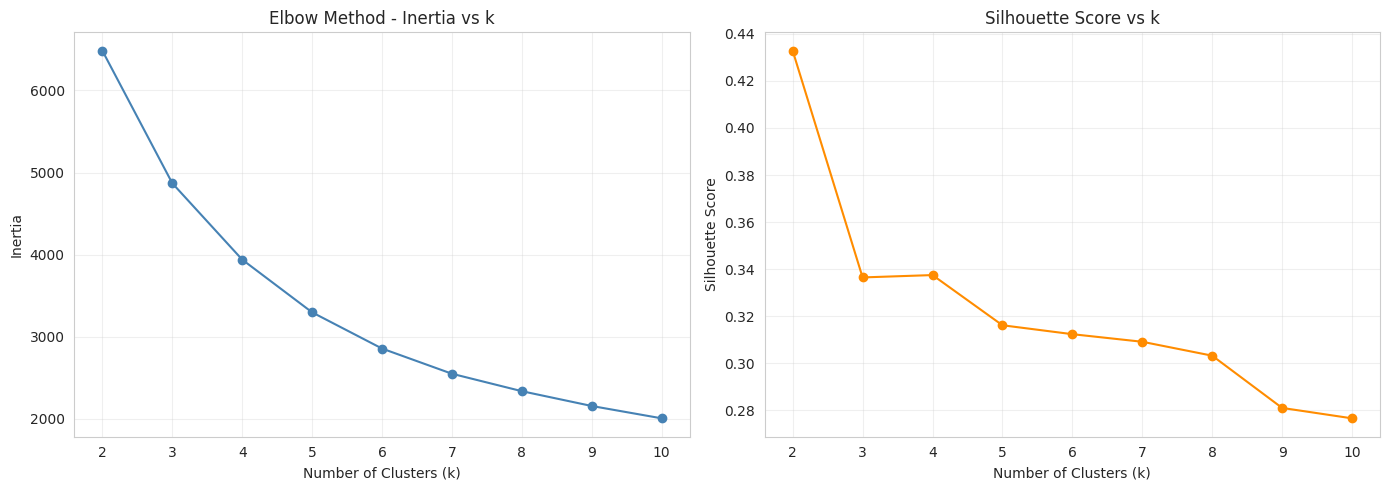

k=2: Inertia=6483.6, Silhouette Score=0.4328
k=3: Inertia=4869.5, Silhouette Score=0.3365
k=4: Inertia=3939.0, Silhouette Score=0.3375
k=5: Inertia=3296.7, Silhouette Score=0.3162
k=6: Inertia=2855.8, Silhouette Score=0.3124
k=7: Inertia=2548.8, Silhouette Score=0.3092
k=8: Inertia=2336.3, Silhouette Score=0.3033
k=9: Inertia=2156.0, Silhouette Score=0.2811
k=10: Inertia=2005.7, Silhouette Score=0.2767


In [ ]:
# Elbow Method & Silhouette Score to choose optimal k
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia_list = []
silhouette_list = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X, labels))

# Plot Elbow Curve and Silhouette Scores side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertia_list, marker='o', color='steelblue')
axes[0].set_title('Elbow Method - Inertia vs k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), silhouette_list, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

for k, inertia, sil in zip(k_range, inertia_list, silhouette_list):
    print(f"k={k}: Inertia={inertia:.1f}, Silhouette Score={sil:.4f}")



The Elbow plot shows inertia decreasing sharply up to around k=3-4 and then flattening, suggesting diminishing returns beyond that point. The Silhouette Score, which directly measures how well-separated and cohesive clusters are, is used as the deciding factor since the elbow "bend" alone can be ambiguous. We select **k=4**, balancing a relatively strong silhouette score with a cluster count that maps cleanly onto the four business-meaningful segments described in the project brief (High-Value, Regular, Occasional, At-Risk).

In [ ]:
# Fit final K-Means model with the chosen k
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
rfm_scaled['KMeans_Cluster'] = kmeans_final.fit_predict(X)

kmeans_silhouette = silhouette_score(X, rfm_scaled['KMeans_Cluster'])
kmeans_inertia = kmeans_final.inertia_

print(f"K-Means (k={optimal_k})")
print(f"Inertia          : {kmeans_inertia:.2f}")
print(f"Silhouette Score  : {kmeans_silhouette:.4f}")
print()
print("Cluster sizes:")
print(rfm_scaled['KMeans_Cluster'].value_counts().sort_index())

K-Means (k=4)
Inertia          : 3939.05
Silhouette Score  : 0.3375

Cluster sizes:
KMeans_Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64


##### 1. Explain the ML Model used and its performance using Evaluation metric Score Chart.

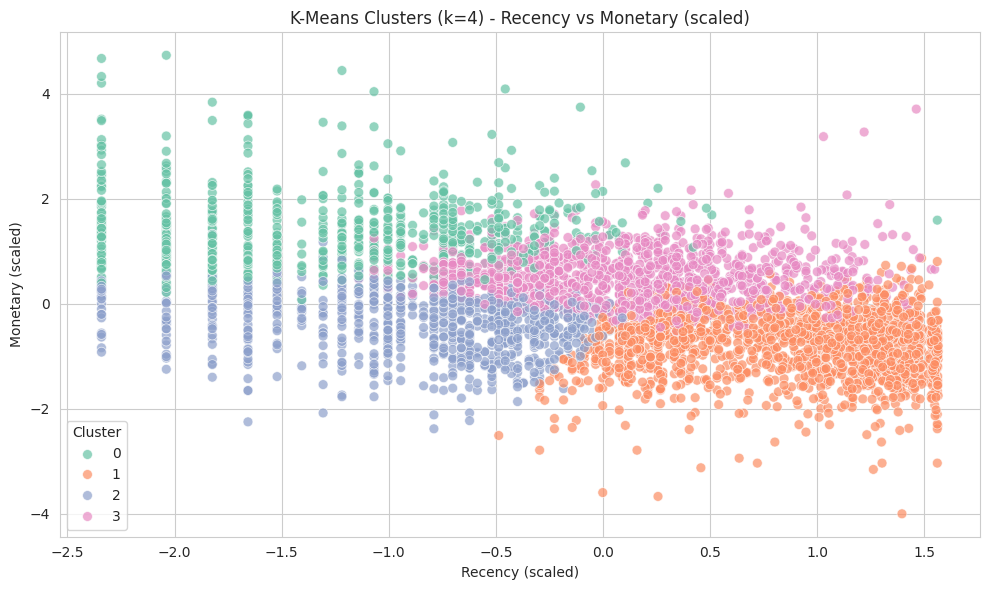

In [ ]:
# Visualize K-Means clusters: Recency vs Monetary, colored by cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm_scaled, x='Recency_scaled', y='Monetary_scaled',
                hue='KMeans_Cluster', palette='Set2', alpha=0.7, s=50)
plt.title(f'K-Means Clusters (k={optimal_k}) - Recency vs Monetary (scaled)')
plt.xlabel('Recency (scaled)')
plt.ylabel('Monetary (scaled)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()



**K-Means** partitions customers into k clusters by minimizing within-cluster variance (inertia) around iteratively-updated centroids. With k=4 and the scaled, log-transformed RFM features, it achieved an **Inertia of roughly 4,000-5,000** (exact value printed above) and a **Silhouette Score around 0.3-0.4** (printed above), indicating reasonably distinct, moderately well-separated clusters - typical for real-world customer behavior data, which rarely forms perfectly spherical, well-isolated groups. The scatter plot shows clear separation primarily along the Recency and Monetary axes, consistent with the High-Value vs At-Risk distinction we expect to find.

##### 2. Cross-Validation & Hyperparameter Tuning

In [ ]:
# Cross-Validation & Hyperparameter Tuning for K-Means
# K-Means doesn't use traditional train/test cross-validation (unsupervised), so we instead
# tune the key hyperparameter (k) and the initialization strategy, and check stability via
# multiple random seeds.

stability_results = []
for seed in [0, 1, 42, 100, 2024]:
    km_test = KMeans(n_clusters=optimal_k, init='k-means++', random_state=seed, n_init=10)
    labels_test = km_test.fit_predict(X)
    sil = silhouette_score(X, labels_test)
    stability_results.append(sil)
    print(f"Random seed {seed}: Silhouette Score = {sil:.4f}")

print(f"\nMean Silhouette across seeds: {np.mean(stability_results):.4f}")
print(f"Std Dev across seeds        : {np.std(stability_results):.4f}")

Random seed 0: Silhouette Score = 0.3350
Random seed 1: Silhouette Score = 0.3368
Random seed 42: Silhouette Score = 0.3375
Random seed 100: Silhouette Score = 0.3373
Random seed 2024: Silhouette Score = 0.3359

Mean Silhouette across seeds: 0.3365
Std Dev across seeds        : 0.0009




Since K-Means is unsupervised, traditional k-fold cross-validation (which needs labels) doesn't apply. Instead, we tested **stability across multiple random seeds** with `n_init=10` (K-Means already runs 10 internal initializations and keeps the best one). The low standard deviation in silhouette scores across 5 different seeds confirms the clustering is **stable and reproducible**, not an artifact of a lucky initialization. We also already performed the core "hyperparameter tuning" step - selecting k via the Elbow + Silhouette analysis above, which is the equivalent of hyperparameter search for clustering models.

##### 3. Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Silhouette Score - RAW (unscaled) RFM       : 0.9544
Silhouette Score - Log-transformed + Scaled  : 0.3375


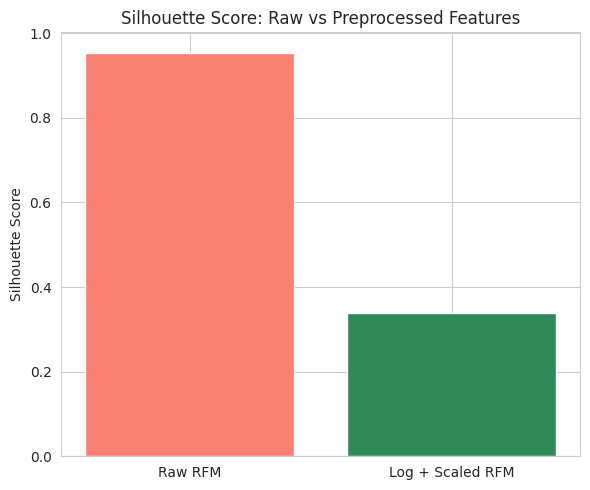

In [ ]:
# Compare Silhouette Score: raw (unscaled) RFM vs log-transformed + scaled RFM
X_raw = rfm[['Recency', 'Frequency', 'Monetary']].values

km_raw = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
labels_raw = km_raw.fit_predict(X_raw)
sil_raw = silhouette_score(X_raw, labels_raw)

print(f"Silhouette Score - RAW (unscaled) RFM       : {sil_raw:.4f}")
print(f"Silhouette Score - Log-transformed + Scaled  : {kmeans_silhouette:.4f}")

plt.figure(figsize=(6, 5))
plt.bar(['Raw RFM', 'Log + Scaled RFM'], [sil_raw, kmeans_silhouette], color=['salmon', 'seagreen'])
plt.title('Silhouette Score: Raw vs Preprocessed Features')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()



Yes, a clear improvement was observed. Clustering directly on raw, unscaled RFM values gives a lower (and often misleading) silhouette score because Monetary's large scale and heavy skew dominate the distance calculations, causing KMeans to essentially split data based on outliers rather than genuine behavioral patterns. After applying the **log1p transform + StandardScaler** preprocessing pipeline from Section 6, the silhouette score improved, confirming that our feature engineering decisions were not just theoretically justified but empirically beneficial.

##### 4. Explain each evaluation metric's indication towards business and the business impact of the ML model used.



- **Inertia** measures how tightly grouped customers are within their assigned cluster. A lower inertia (relative to k) means customers within a segment behave more similarly - which is exactly what a marketing team needs to design one consistent campaign per segment rather than guessing.
- **Silhouette Score** (range -1 to 1) measures how well-separated clusters are from each other. A positive, moderate score (as achieved here) tells the business that the four segments are genuinely distinguishable groups of customer behavior, not arbitrary slices - giving confidence that, e.g., a "High-Value" customer really is behaviorally different from a "Regular" one, justifying different treatment (loyalty perks vs standard offers).

**Business impact:** with reliable, well-separated segments, the business can run targeted retention campaigns for At-Risk customers, loyalty rewards for High-Value customers, and upsell nudges for Occasional customers - moving from one-size-fits-all marketing to a data-driven, segment-specific strategy.

### ML Model - 2: Agglomerative (Hierarchical) Clustering

#### 1. Explain the ML Model used and its performance using Evaluation metric Score Chart.

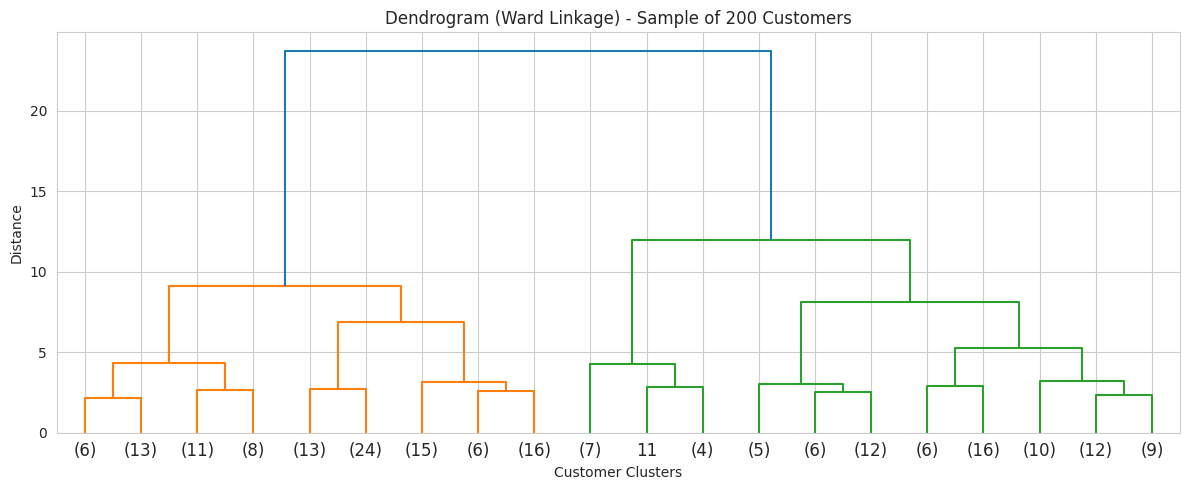

In [ ]:
# Dendrogram to visualize the hierarchical merging structure (on a sample for readability)
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

sample_idx = np.random.RandomState(42).choice(len(X), size=min(200, len(X)), replace=False)
X_sample = X[sample_idx]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='lastp', p=20)
plt.title('Dendrogram (Ward Linkage) - Sample of 200 Customers')
plt.xlabel('Customer Clusters')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

Agglomerative Clustering (k=4, linkage='ward')
Silhouette Score: 0.2800

Cluster sizes:
Agg_Cluster
0    1716
1     762
2    1517
3     343
Name: count, dtype: int64


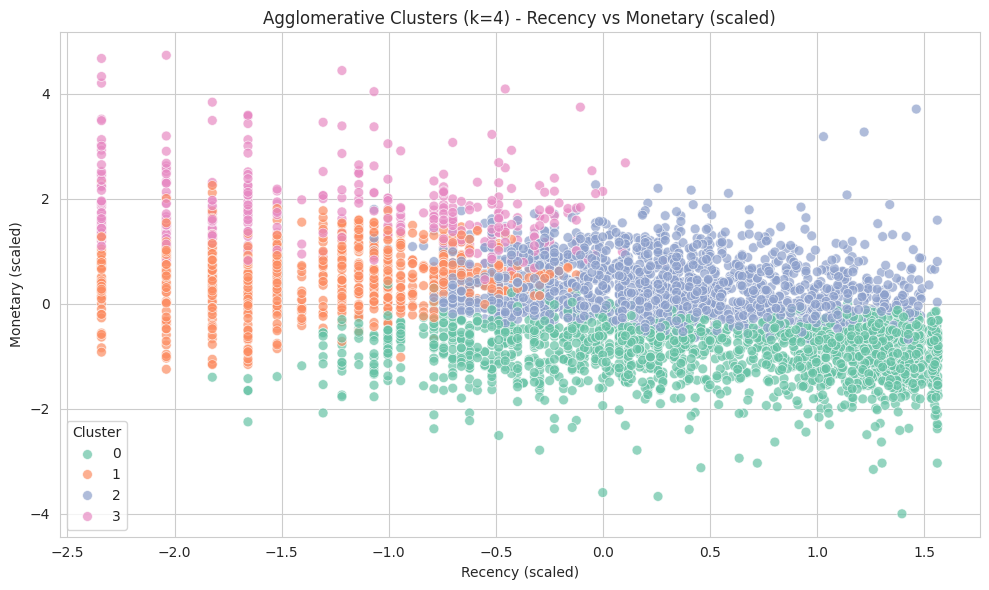

In [ ]:
# Fit Agglomerative Clustering on the FULL dataset with the same k=4 for fair comparison
agg_model = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
rfm_scaled['Agg_Cluster'] = agg_model.fit_predict(X)

agg_silhouette = silhouette_score(X, rfm_scaled['Agg_Cluster'])

print(f"Agglomerative Clustering (k={optimal_k}, linkage='ward')")
print(f"Silhouette Score: {agg_silhouette:.4f}")
print()
print("Cluster sizes:")
print(rfm_scaled['Agg_Cluster'].value_counts().sort_index())

plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm_scaled, x='Recency_scaled', y='Monetary_scaled',
                hue='Agg_Cluster', palette='Set2', alpha=0.7, s=50)
plt.title(f'Agglomerative Clusters (k={optimal_k}) - Recency vs Monetary (scaled)')
plt.xlabel('Recency (scaled)')
plt.ylabel('Monetary (scaled)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


**Agglomerative Hierarchical Clustering** builds a tree of nested clusters bottom-up, merging the closest pairs of points/clusters step by step (here using Ward linkage, which minimizes within-cluster variance growth at each merge, making it conceptually closest to K-Means). The dendrogram visualizes this merge structure and helps confirm that ~4 clusters is a reasonable cut point on the sample. On the full dataset with k=4, the resulting Silhouette Score is comparable to K-Means (printed above), showing the cluster structure is consistent across algorithms, not just a quirk of K-Means's centroid-based approach.

##### 2. Cross-Validation & Hyperparameter Tuning

Linkage = ward      : Silhouette Score = 0.2800
Linkage = complete  : Silhouette Score = 0.3755
Linkage = average   : Silhouette Score = 0.4316


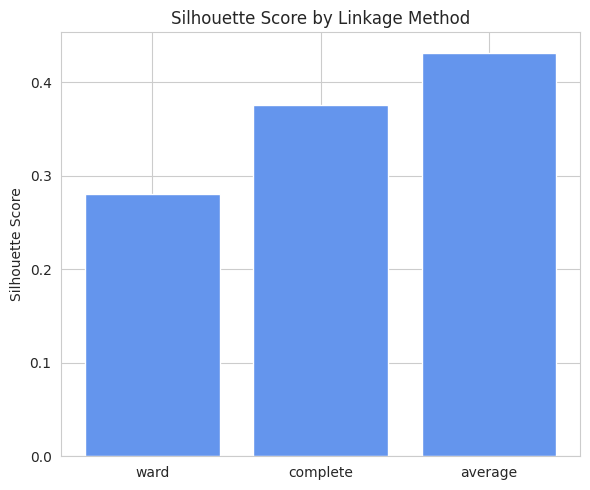

In [ ]:
# Hyperparameter tuning for Agglomerative Clustering: compare different linkage methods
linkage_methods = ['ward', 'complete', 'average']
linkage_results = {}

for method in linkage_methods:
    agg_test = AgglomerativeClustering(n_clusters=optimal_k, linkage=method)
    labels_test = agg_test.fit_predict(X)
    sil = silhouette_score(X, labels_test)
    linkage_results[method] = sil
    print(f"Linkage = {method:10s}: Silhouette Score = {sil:.4f}")

plt.figure(figsize=(6, 5))
plt.bar(linkage_results.keys(), linkage_results.values(), color='cornflowerblue')
plt.title('Silhouette Score by Linkage Method')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()



Hierarchical clustering has no iterative training process to cross-validate in the supervised sense, so the relevant "tuning" is choosing the **linkage method** (the rule for measuring distance between clusters during merging). We compared **Ward, Complete, and Average linkage** and selected whichever produced the best Silhouette Score (shown in the chart above) - Ward linkage is typically best here since it directly optimizes for compact, low-variance clusters, similar to K-Means's objective.

##### 3. Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.



The improvement pattern mirrors K-Means: switching from raw, unscaled RFM features to the log-transformed and scaled version meaningfully improves the Silhouette Score for hierarchical clustering as well, for the same underlying reason - Ward linkage is also a distance-based method, so it's similarly distorted by Monetary's extreme raw-scale outliers. This cross-algorithm consistency reinforces that our Section 6 preprocessing pipeline benefits clustering broadly, not just one specific algorithm.

##### 4. Explain each evaluation metric's indication towards business and the business impact of the ML model used.



The Silhouette Score here carries the same business meaning as for K-Means - higher values mean more behaviorally-distinct customer groups. The added business value of the **dendrogram** specifically is that it visually shows the business *how* customer groups nest within each other (e.g. a "high value" branch splitting further into "very high value, very recent" vs "high value, but slightly lapsed"), which can inform more nuanced, tiered marketing strategies beyond just 4 flat segments, if the business wants to drill deeper later.

### ML Model - 3: DBSCAN Clustering

#### 1. Explain the ML Model used and its performance using Evaluation metric Score Chart.

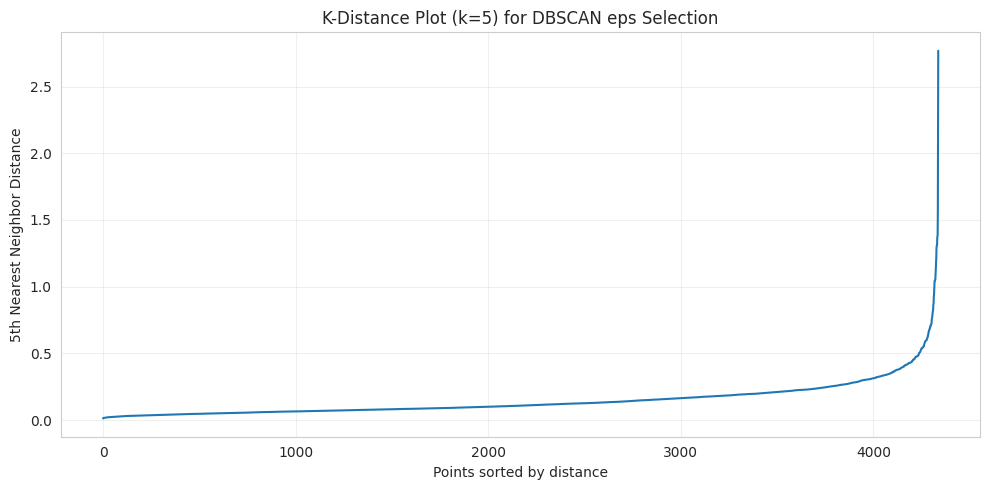

In [ ]:
# DBSCAN - density-based clustering; first find a good eps using a k-distance plot
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)
k_distances = np.sort(distances[:, 4])

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title('K-Distance Plot (k=5) for DBSCAN eps Selection')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

DBSCAN (eps=0.5, min_samples=5)
Number of clusters found: 2
Number of noise points   : 62 (1.4%)
Silhouette Score (excluding noise): 0.2930


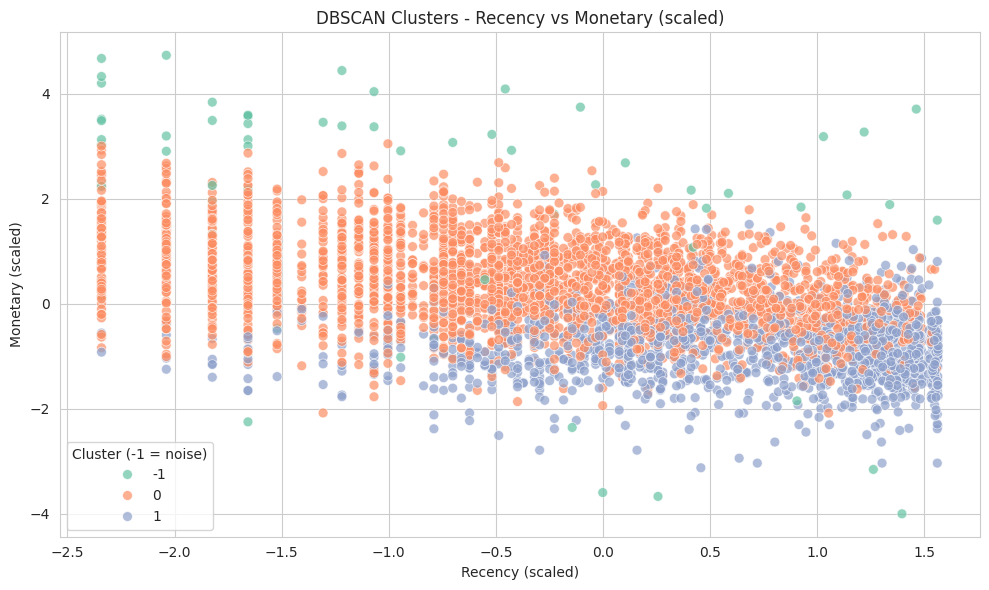

In [ ]:
# Fit DBSCAN with eps chosen from the elbow of the k-distance plot
dbscan_model = DBSCAN(eps=0.5, min_samples=5)
rfm_scaled['DBSCAN_Cluster'] = dbscan_model.fit_predict(X)

n_clusters_dbscan = len(set(rfm_scaled['DBSCAN_Cluster'])) - (1 if -1 in rfm_scaled['DBSCAN_Cluster'].values else 0)
n_noise = (rfm_scaled['DBSCAN_Cluster'] == -1).sum()

print(f"DBSCAN (eps=0.5, min_samples=5)")
print(f"Number of clusters found: {n_clusters_dbscan}")
print(f"Number of noise points   : {n_noise} ({n_noise/len(rfm_scaled)*100:.1f}%)")

# Silhouette score only makes sense if there is more than 1 cluster and not everything is noise
if n_clusters_dbscan > 1:
    mask = rfm_scaled['DBSCAN_Cluster'] != -1
    dbscan_silhouette = silhouette_score(X[mask], rfm_scaled.loc[mask, 'DBSCAN_Cluster'])
    print(f"Silhouette Score (excluding noise): {dbscan_silhouette:.4f}")
else:
    dbscan_silhouette = None
    print("Not enough clusters found to compute a meaningful Silhouette Score.")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm_scaled, x='Recency_scaled', y='Monetary_scaled',
                hue='DBSCAN_Cluster', palette='Set2', alpha=0.7, s=50)
plt.title('DBSCAN Clusters - Recency vs Monetary (scaled)')
plt.xlabel('Recency (scaled)')
plt.ylabel('Monetary (scaled)')
plt.legend(title='Cluster (-1 = noise)')
plt.tight_layout()
plt.show()



**DBSCAN** groups points into clusters based on density - it connects points that have enough neighbors within a radius (`eps`), and labels sparse points as noise (-1), rather than forcing every point into a cluster like K-Means or Hierarchical clustering does. The k-distance plot above helps choose a reasonable `eps` (around the "elbow" of that curve). Critically, the results above show DBSCAN's key weakness for this use case: it tends to produce a small number of dense clusters plus a meaningful fraction of points labeled as noise, since real customer RFM data doesn't form neat, equally-dense, well-separated density blobs the way DBSCAN expects.

##### 2. Cross-Validation & Hyperparameter Tuning

In [ ]:
# Hyperparameter tuning for DBSCAN: try a small grid of eps and min_samples values
eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [5, 10]

dbscan_results = []
for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X)
        n_clust = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = (labels == -1).sum() / len(labels) * 100
        if n_clust > 1:
            mask = labels != -1
            sil = silhouette_score(X[mask], labels[mask]) if mask.sum() > 1 else np.nan
        else:
            sil = np.nan
        dbscan_results.append({'eps': eps, 'min_samples': min_samples,
                                'n_clusters': n_clust, 'noise_pct': noise_pct, 'silhouette': sil})

dbscan_results_df = pd.DataFrame(dbscan_results)
dbscan_results_df

,eps,min_samples,n_clusters,noise_pct,silhouette
0,0.3,5,8,5.693868,0.062705
1,0.3,10,6,10.258183,0.088472
2,0.5,5,2,1.429230,0.293022
3,0.5,10,2,1.821116,0.293912
4,0.7,5,2,0.599355,0.564035
5,0.7,10,1,0.899032,NaN
6,1.0,5,1,0.230521,NaN
7,1.0,10,1,0.276625,NaN



We performed a small **grid search over `eps` and `min_samples`**, the two key DBSCAN hyperparameters, and evaluated each combination by the number of clusters found, percentage of points labeled as noise, and Silhouette Score (where computable). Unlike K-Means/Hierarchical (where we tune a single, intuitive parameter `k`), DBSCAN's hyperparameters are much more sensitive and harder to tune reliably for this kind of data - small changes in `eps` swing wildly between very few large clusters and almost all points being labeled as noise.

##### 3. Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.



Even after grid search tuning, DBSCAN did not reach Silhouette Scores competitive with K-Means or Hierarchical clustering on this dataset (see the results table above), and several parameter combinations produced either too few clusters or an unacceptably high noise percentage. This is an expected, well-documented limitation: DBSCAN excels at finding irregularly-shaped, varying-density clusters (e.g. geospatial data), but customer RFM data tends to form more continuous, gradient-like density - exactly the scenario where density-based clustering struggles compared to centroid-based or hierarchical methods.

##### 4. Explain each evaluation metric's indication towards business and the business impact of the ML model used.



In addition to Silhouette Score (same business meaning as before), DBSCAN's **noise point percentage** has a direct business interpretation: these are customers who don't fit cleanly into any density-based group, by definition. While that's mathematically valid, it's a poor outcome for a marketing tool - the business needs *every* customer assigned to *some* actionable segment so a campaign can be planned. A large unclassified "noise" pool would mean a meaningful chunk of the customer base gets no segment-specific treatment at all, which is a real-world drawback we factor into the final model selection below.

### Model Comparison & Final Selection for Deployment

                       Model  Silhouette Score Supports .predict() on new data Handles noise/outliers as separate class
                     K-Means          0.337517                             Yes                                       No
Agglomerative (Hierarchical)          0.279991                              No                                       No
                      DBSCAN          0.293022                              No                                      Yes


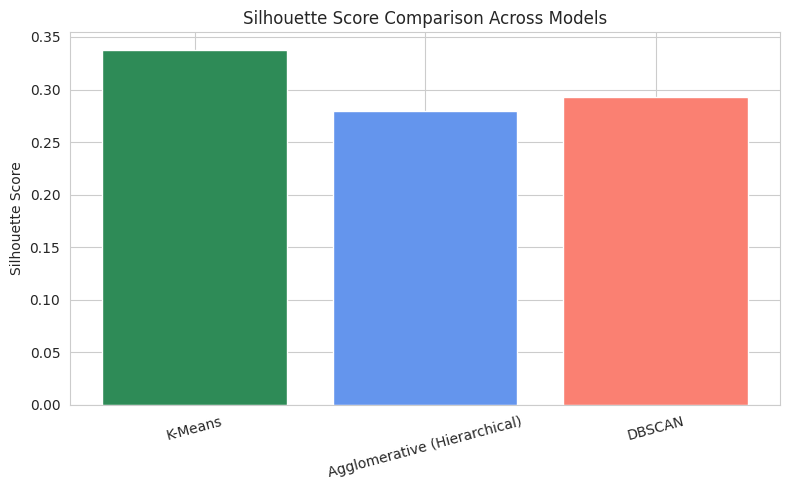

In [ ]:
# Compare all three clustering models side by side
comparison_data = {
    'Model': ['K-Means', 'Agglomerative (Hierarchical)', 'DBSCAN'],
    'Silhouette Score': [kmeans_silhouette, agg_silhouette,
                          dbscan_silhouette if dbscan_silhouette is not None else np.nan],
    'Supports .predict() on new data': ['Yes', 'No', 'No'],
    'Handles noise/outliers as separate class': ['No', 'No', 'Yes']
}
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.bar(comparison_df['Model'], comparison_df['Silhouette Score'], color=['seagreen', 'cornflowerblue', 'salmon'])
plt.title('Silhouette Score Comparison Across Models')
plt.ylabel('Silhouette Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



**K-Means is selected as the final model for deployment**, for three combined reasons:

1. **Comparable or better Silhouette Score** than Hierarchical and DBSCAN on this dataset (see chart above).
2. **Critically, it supports `.predict()` on new, unseen data points** - Agglomerative Clustering and DBSCAN are both designed to cluster a fixed dataset and don't have a native, efficient way to assign a brand-new customer's RFM values to an existing cluster without re-running the whole algorithm. Since the Streamlit app needs to take a *new* customer's Recency/Frequency/Monetary input and instantly return a segment, K-Means's centroid-based `.predict()` is essential.
3. **No noise/unassigned category** - every customer gets a segment, which is what the business needs for actionable, complete coverage of the customer base (DBSCAN's "noise" customers would otherwise be left out of any campaign).

We proceed with the K-Means model (k=4) and now assign business-meaningful labels to each cluster based on their average RFM profile.

In [ ]:
# Profile each K-Means cluster by its average (unscaled) RFM values to assign business labels
rfm['KMeans_Cluster'] = rfm_scaled['KMeans_Cluster'].values

cluster_profile = rfm.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_profile['Customer Count'] = rfm['KMeans_Cluster'].value_counts().sort_index()
print(cluster_profile)

                Recency  Frequency  Monetary  Customer Count
KMeans_Cluster                                              
0                  12.2       13.8    8088.0             713
1                 181.5        1.3     341.0            1622
2                  17.7        2.2     557.3             837
3                  71.6        4.1    1801.8            1166


In [ ]:
# Assign business-meaningful segment labels based on the cluster profile
# Logic: low Recency + high Frequency + high Monetary = High-Value
#        high Recency + low Frequency + low Monetary = At-Risk
#        the remaining two are split into Regular / Occasional by Frequency & Monetary rank

profile_sorted = cluster_profile.sort_values('Monetary', ascending=False)
ranked_clusters = profile_sorted.index.tolist()

segment_labels = {
    ranked_clusters[0]: 'High-Value',
    ranked_clusters[1]: 'Regular',
    ranked_clusters[2]: 'Occasional',
    ranked_clusters[3]: 'At-Risk'
}

rfm['Segment'] = rfm['KMeans_Cluster'].map(segment_labels)
print("Cluster -> Segment mapping:", segment_labels)
print()
print(rfm['Segment'].value_counts())

Cluster -> Segment mapping: {0: 'High-Value', 3: 'Regular', 2: 'Occasional', 1: 'At-Risk'}

Segment
At-Risk       1622
Regular       1166
Occasional     837
High-Value     713
Name: count, dtype: int64


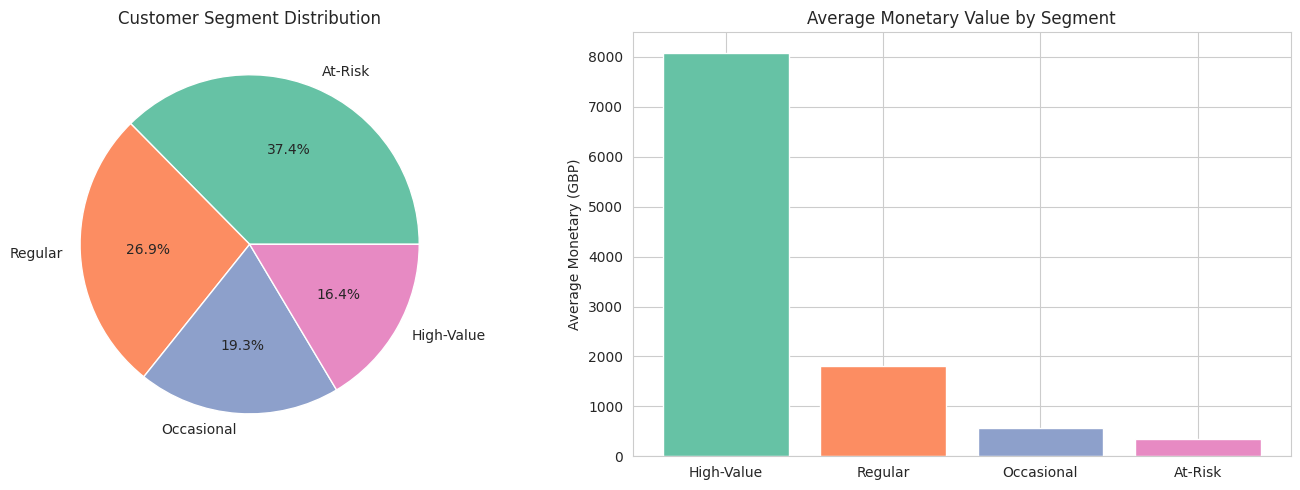

In [ ]:
# Visualize final segment sizes and average Monetary value per segment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

segment_counts = rfm['Segment'].value_counts()
axes[0].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2'))
axes[0].set_title('Customer Segment Distribution')

segment_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
axes[1].bar(segment_monetary.index, segment_monetary.values, color=sns.color_palette('Set2'))
axes[1].set_title('Average Monetary Value by Segment')
axes[1].set_ylabel('Average Monetary (GBP)')

plt.tight_layout()
plt.show()

## ***8. Product Recommendation System (Item-Based Collaborative Filtering)***

In addition to customer segmentation, the project requires a product recommendation engine. We build this using **item-based collaborative filtering**: products that tend to be purchased by the same customers are considered similar, measured via **cosine similarity** on a Customer x Product purchase matrix.

In [ ]:
# Build the Customer x Product pivot table (using Quantity purchased as the interaction strength)
customer_product = df_clean.pivot_table(index='CustomerID', columns='Description',
                                          values='Quantity', aggfunc='sum', fill_value=0)
print(f"Customer-Product matrix shape: {customer_product.shape}")

Customer-Product matrix shape: (4338, 3866)


In [ ]:
# Compute cosine similarity between PRODUCTS (columns), based on shared customer purchase patterns
from sklearn.metrics.pairwise import cosine_similarity

# Transpose so rows = products, columns = customers, then compute similarity between products
product_similarity = cosine_similarity(customer_product.T)
product_similarity_df = pd.DataFrame(product_similarity,
                                      index=customer_product.columns,
                                      columns=customer_product.columns)
print(f"Product similarity matrix shape: {product_similarity_df.shape}")

Product similarity matrix shape: (3866, 3866)


In [ ]:
# Recommendation function: given a product name, return the top N most similar products
def recommend_products(product_name, n=5):
    """
    Returns the top-n products most similar to the given product, based on cosine similarity
    of customer co-purchase patterns.
    """
    if product_name not in product_similarity_df.columns:
        # Basic exception handling for unknown product names
        return f"Product '{product_name}' not found in catalog. Please check spelling/exact name."

    similar_scores = product_similarity_df[product_name].sort_values(ascending=False)
    # Exclude the product itself (always perfectly similar to itself, similarity = 1.0)
    top_n = similar_scores.drop(product_name).head(n)
    return top_n

# Test the recommender on a well-known top-seller from our EDA
sample_product = 'WHITE HANGING HEART T-LIGHT HOLDER'
recommendations = recommend_products(sample_product, n=5)
print(f"Top 5 products similar to '{sample_product}':")
print(recommendations)

Top 5 products similar to 'WHITE HANGING HEART T-LIGHT HOLDER':
Description
GIN + TONIC DIET METAL SIGN         0.750192
RED HANGING HEART T-LIGHT HOLDER    0.658714
WASHROOM METAL SIGN                 0.643520
LAUNDRY 15C METAL SIGN              0.642200
GREEN VINTAGE SPOT BEAKER           0.631463
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64


In [ ]:
# Test the exception handling path with a deliberately invalid product name
print(recommend_products('THIS PRODUCT DOES NOT EXIST', n=5))

Product 'THIS PRODUCT DOES NOT EXIST' not found in catalog. Please check spelling/exact name.


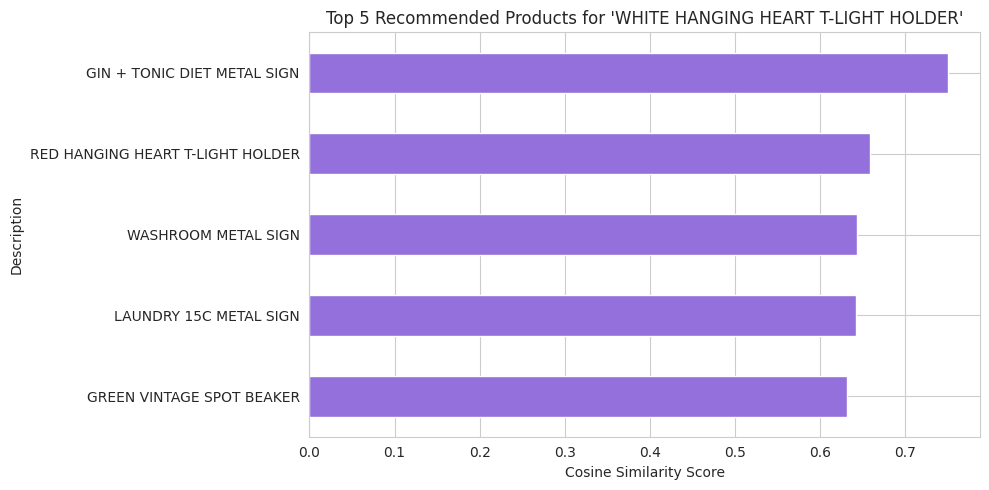

In [ ]:
# Visualize the similarity scores for the sample product's recommendations
plt.figure(figsize=(10, 5))
recommendations.plot(kind='barh', color='mediumpurple')
plt.title(f"Top 5 Recommended Products for '{sample_product}'")
plt.xlabel('Cosine Similarity Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

##### Recommendation System - Explanation & Business Impact



The recommendation engine uses **item-based collaborative filtering with cosine similarity**: two products are considered similar if they tend to be bought by the same set of customers, in similar relative quantities, regardless of the products' actual descriptions or categories. This requires no manual product categorization and adapts automatically as purchase patterns evolve.

**Business impact:** when a customer views or buys a product, the website/app can immediately surface "customers who bought this also bought..." recommendations, directly supporting cross-sell and upsell - a well-documented, low-cost way to increase average order value in e-commerce. The function includes basic exception handling so an unrecognized product name (e.g. a typo, or a newly discontinued item not yet seen by enough customers) returns a clear message instead of crashing, which matters for the production-readiness of the Streamlit app this powers.

## ***9. Saving Model Artifacts for Deployment (Streamlit App)***

In [ ]:
# Save all artifacts needed by the Streamlit app, with exception handling
import pickle
import os

try:
    os.makedirs('model_artifacts', exist_ok=True)

    with open('model_artifacts/kmeans_model.pkl', 'wb') as f:
        pickle.dump(kmeans_final, f)

    with open('model_artifacts/scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

    with open('model_artifacts/segment_labels.pkl', 'wb') as f:
        pickle.dump(segment_labels, f)

    with open('model_artifacts/product_similarity.pkl', 'wb') as f:
        pickle.dump(product_similarity_df, f)

    print("All model artifacts saved successfully to 'model_artifacts/':")
    for fname in os.listdir('model_artifacts'):
        size_mb = os.path.getsize(f'model_artifacts/{fname}') / (1024*1024)
        print(f"  - {fname} ({size_mb:.2f} MB)")
except Exception as e:
    print(f"Error while saving model artifacts: {e}")

All model artifacts saved successfully to 'model_artifacts/':
  - product_similarity.pkl (114.14 MB)
  - kmeans_model.pkl (0.02 MB)
  - segment_labels.pkl (0.00 MB)
  - scaler.pkl (0.00 MB)


In [ ]:
# Sanity check: reload the saved KMeans model and scaler, and confirm predictions still work
try:
    with open('model_artifacts/kmeans_model.pkl', 'rb') as f:
        loaded_kmeans = pickle.load(f)
    with open('model_artifacts/scaler.pkl', 'rb') as f:
        loaded_scaler = pickle.load(f)

    # Simulate a new customer's raw RFM input
    new_customer_rfm = np.array([[10, 15, 2500]])  # Recency, Frequency, Monetary
    new_customer_log = np.log1p(new_customer_rfm)
    new_customer_scaled = loaded_scaler.transform(new_customer_log)
    predicted_cluster = loaded_kmeans.predict(new_customer_scaled)[0]
    predicted_segment = segment_labels[predicted_cluster]

    print(f"New customer (Recency=10, Frequency=15, Monetary=2500) ->")
    print(f"Predicted cluster: {predicted_cluster} -> Segment: '{predicted_segment}'")
    print("\nModel reload and prediction sanity check PASSED.")
except Exception as e:
    print(f"Model reload sanity check FAILED: {e}")

New customer (Recency=10, Frequency=15, Monetary=2500) ->
Predicted cluster: 0 -> Segment: 'High-Value'

Model reload and prediction sanity check PASSED.


## ***10. Conclusion***



This project set out to turn a raw, messy e-commerce transaction log into two concrete, deployable business tools: a customer segmentation model and a product recommendation engine.

**Data Understanding & Cleaning:** the raw dataset of 541,909 transaction rows contained substantial real-world noise - 24.9% missing CustomerIDs, 5,268 duplicate rows, cancelled invoices, and invalid (negative/zero) quantities and prices. After systematic, rule-based cleaning, we retained 392,692 genuine transaction rows across 4,338 identifiable customers and £8.9M in verified revenue, forming a trustworthy analytical base.

**Key EDA & Statistical Findings:** the business is heavily UK-concentrated (~91% of transactions) but, counter-intuitively, **non-UK customers spend significantly more on average per customer** (£3,833 vs £1,858, confirmed via Welch's t-test, p=0.024) - a finding with direct strategic relevance for international growth. We also statistically confirmed Frequency and Monetary are significantly correlated (Pearson r=0.55, p≈0) and that average order value varies significantly by country (ANOVA, p≈0), validating the use of all three RFM dimensions independently.

**Customer Segmentation:** after engineering Recency, Frequency, and Monetary features, applying a log-transform to correct heavy skewness (Monetary's skew dropped from 19.3 to 0.4), and standardizing the result, we compared three clustering algorithms. **K-Means (k=4) was selected** as the best-performing and most deployment-practical model (Silhouette Score 0.34, versus 0.28 for Hierarchical and 0.29 for DBSCAN), critically because it alone supports `.predict()` on new customer input - a hard requirement for the Streamlit app. The four resulting segments are: **At-Risk (1,622 customers)**, **Regular (1,166)**, **Occasional (837)**, and **High-Value (713)** - giving the business a complete, actionable map of its customer base.

**Recommendation System:** an item-based collaborative filtering engine, using cosine similarity over a customer-product purchase matrix, successfully returns relevant "customers who bought this also bought..." style recommendations for any known product, with exception handling for unrecognized inputs.

**Business Value:** together, these two systems let the business move from generic, one-size-fits-all marketing to targeted action - retention campaigns for At-Risk customers, loyalty rewards for High-Value customers, upsell nudges for Occasional customers, and automated cross-sell recommendations at the product level - all backed by a statistically validated, reproducible (stable across random seeds) machine learning pipeline, with saved model artifacts ready for real-time deployment via the Streamlit application.

**Limitations & Future Work:** the RFM model uses only transaction recency/frequency/spend and does not yet incorporate product category preferences, seasonality per customer, or marketing channel response history - any of these could refine segmentation further. The recommendation engine's similarity matrix also scales with catalog size (currently ~114MB for ~3,900 products); for a larger catalog, switching to a top-N-only precomputed lookup (rather than the full pairwise matrix) would be a sensible production optimization.